In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/2
    print("準備完了！このまま下のセルを実行できます。")

# 第2章 確率の規則 (The Rules of Probability)

本ノートブックは、教科書『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』(Bishop & Bishop, 2024) の **第2章「確率 (Probabilities)」および 2.1節「確率の規則 (The Rules of Probability)」** を完全に再現・解説するものです。

深層学習を含む現代の機械学習において、パターン認識や予測の本質は「**不確実性の適切な定量化と管理 (quantifying and manipulating uncertainty)**」にあります。本章では、あらゆる確率的推論の礎となる2つの基本的規則（**加法定理** と **乗法定理**）、およびそれらから導かれる **ベイズの定理** について、数式の厳密な導出、直感的な幾何学的・度数論的解釈、そしてPythonコードによるシミュレーションを通じて深く理解します。

---

## 目次
- [第2章 導入: 不確実性と確率 (Uncertainties and Probabilities)](#chapter2_intro)
  - 認識的不確実性 (Epistemic) vs 偶然的不確実性 (Aleatoric) (Figure 2.1)
  - 確率の2つの解釈: 頻度主義 vs ベイズ主義 (Figure 2.2)
- [2.1.1 A medical screening example](#sec_2_1_1) (Figure 2.3)
- [2.1.2 The sum and product rules](#sec_2_1_2) (Figure 2.4, Figure 2.5)
- [2.1.3 Bayes’ theorem](#sec_2_1_3)
- [2.1.4 Medical screening revisited](#sec_2_1_4)
- [2.1.5 Prior and posterior probabilities](#sec_2_1_5)
- [2.1.6 Independent variables](#sec_2_1_6)
- [まとめと機械学習への展望](#summary)


<a id="chapter2_intro"></a>
### 第2章 導入: 不確実性と確率 (Uncertainties and Probabilities)

機械学習において不確実性（Uncertainty）が生じる要因は、大きく分けて以下の2種類に分類されます：

1. **偶然的不確実性 (Aleatoric uncertainty / irreducible uncertainty)**:
   - システム自身に内在する本質的なランダム性や測定時の物理ノイズに起因する不確実性です。
   - 例: センサーの測定熱雑音、量子効果、サイコロの出目。データをどれだけ大量に集めても（同一条件下では）解消できません。
2. **認識的不確実性 (Epistemic uncertainty / reducible uncertainty)**:
   - 対象に関する「知識や情報の不足（未観測の変数）」に起因する不確実性です。
   - 例: 入力変数の一部が観測されていない場合や、モデルのパラメータを特定する訓練データが不足している場合。追加の測定を行ったり関連する変数を観測することで低減（解消）できます。

#### Figure 2.1: 2次元回帰における2種類の不確実性の例
真の関数が2つの入力 $x_1, x_2$ に依存する次の2次元正弦波であるとします：
$$y(x_1, x_2) = \sin(2\pi x_1) \sin(2\pi x_2)$$
観測データ $t$ は、この関数値に小さなガウスノイズ $\epsilon \sim \mathcal{N}(0, \sigma^2)$（偶然的不確実性）が付加されたものとします：
$$t = y(x_1, x_2) + \epsilon$$

もし $x_2$ が未観測のまま $x_1$ のみから $t$ を予測しようとすると、データは $x_1$ に対して激しくばらつき、非常に大きなノイズ（大きな不確実性）が存在するように見えます（Figure 2.1 (b)）。しかし、この大きなばらつきの大部分は「$x_2$ の値を知らない」という **認識的不確実性** に起因しています。もし $x_2$ を観測または固定できれば（Figure 2.1 (c)）、データは明瞭なサイン曲線を描き、残る不確実性は小さな本質的ノイズ $\epsilon$（偶然的不確実性）のみとなります。


In [1]:
# 環境設定と共通モジュールのインポート
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.path import Path

# プロジェクトルートの common モジュールをインポート
sys.path.append(os.path.abspath('..'))
from common.plot_utils import setup_style, save_plot
from common.probability import (
    generate_2d_sine_data,
    compute_joint_marginal_conditional,
    bayes_rule,
    medical_screening_model,
    check_independence
)

setup_style()
print("Libraries and common modules loaded successfully.")

Libraries and common modules loaded successfully.


#### Figure 2.1 の再現コード
3つのプロットを作成します：
- **(a)** $y(x_1, x_2) = \sin(2\pi x_1)\sin(2\pi x_2)$ の 3D サーフェスプロット
- **(b)** $x_2$ が未観測の場合（$x_2 \in [0, 1]$ で一様分布）の散布図（大きなばらつき＝認識的不確実性）
- **(c)** $x_2$ を固定した場合（$x_2 = 0.25$）の散布図（本来の小さなノイズのみ＝偶然的不確実性）


Figure saved successfully to: result/fig2_01_two_dimensional_regression.png


Figure saved successfully to: ../result/fig2_01_two_dimensional_regression.png


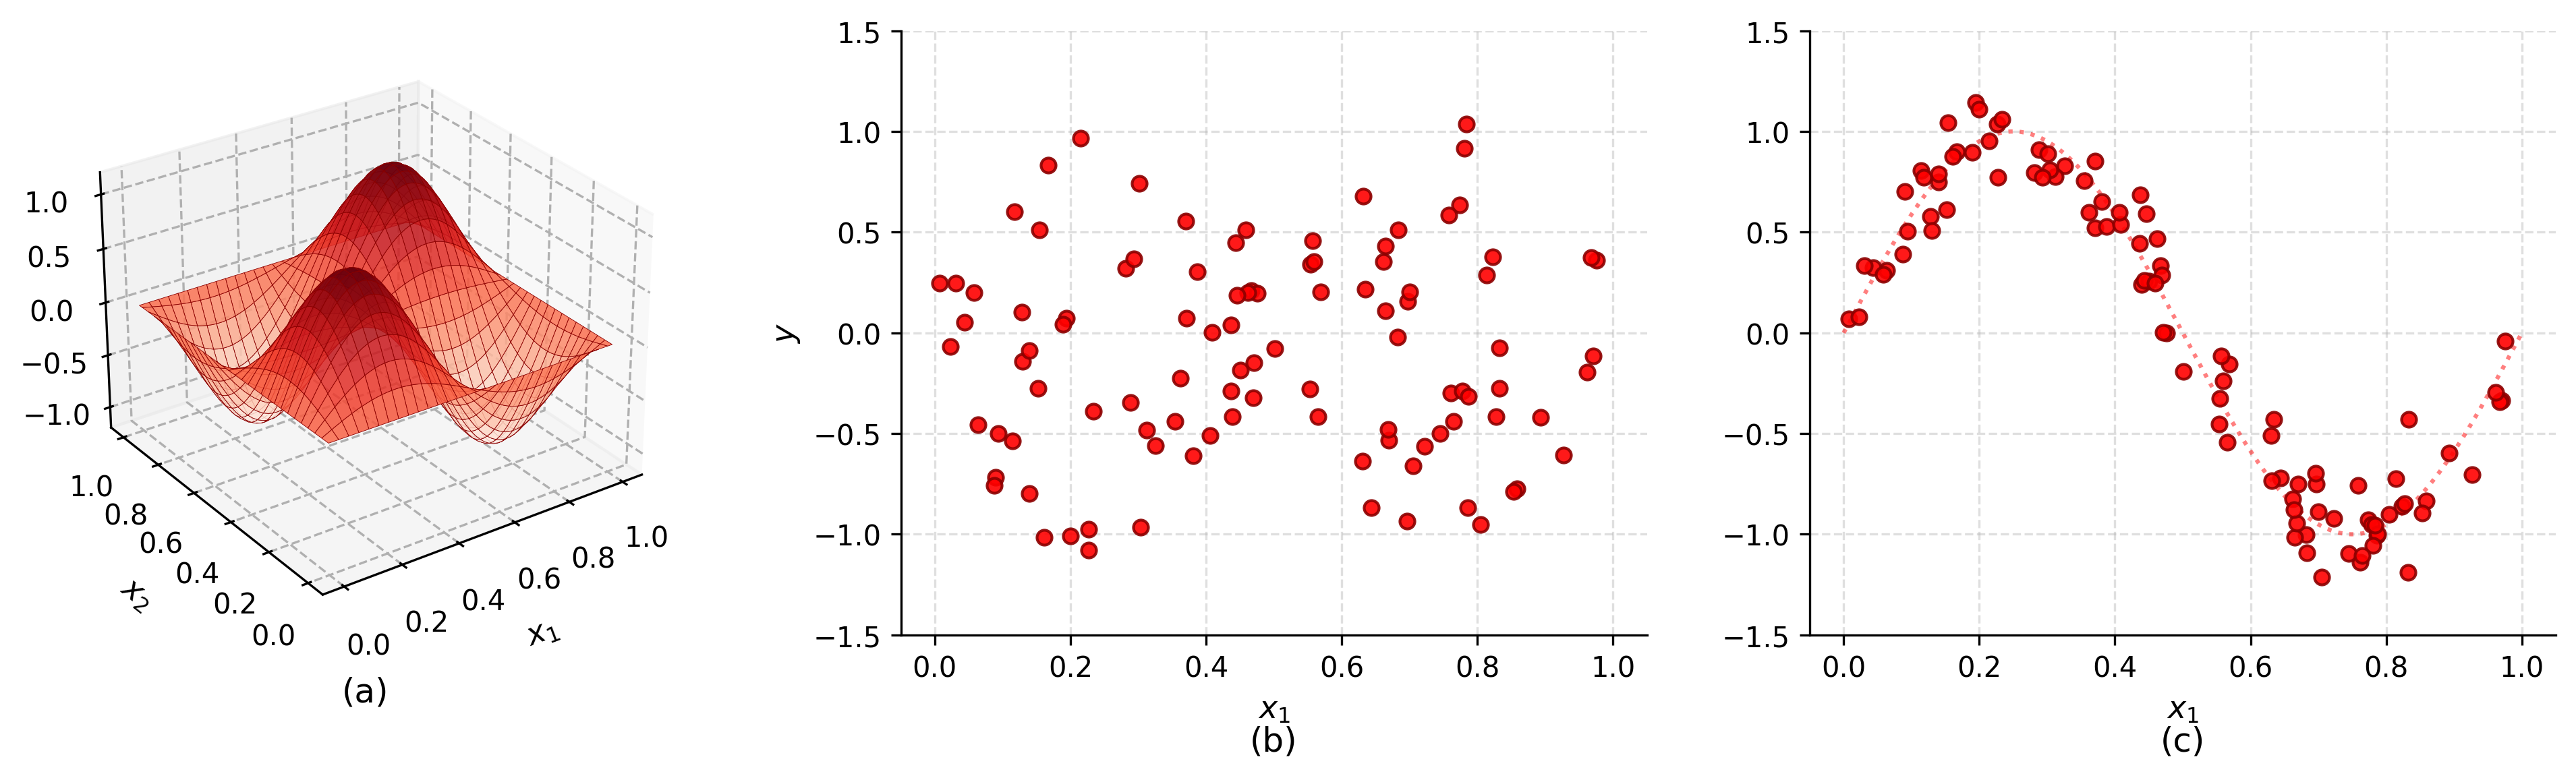

In [2]:
# Figure 2.1: 2次元回帰と不確実性の可視化
fig = plt.figure(figsize=(13, 4), dpi=300)

# (a) 3D Surface
ax_a = fig.add_subplot(1, 3, 1, projection='3d')
x1_grid = np.linspace(0, 1, 60)
x2_grid = np.linspace(0, 1, 60)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Y = np.sin(2 * np.pi * X1) * np.sin(2 * np.pi * X2)

surf = ax_a.plot_surface(
    X1, X2, Y,
    cmap='Reds',
    edgecolor='darkred',
    linewidth=0.2,
    alpha=0.85,
    antialiased=True
)
ax_a.set_xlabel(r'$x_1$', fontsize=11, labelpad=5)
ax_a.set_ylabel(r'$x_2$', fontsize=11, labelpad=5)
ax_a.set_zlabel(r'$y$', fontsize=11, labelpad=5)
ax_a.set_title('(a)', y=-0.15, fontsize=12)
ax_a.view_init(elev=28, azim=-125)
ax_a.set_zlim(-1.2, 1.2)
ax_a.grid(True, alpha=0.3)

# (b) Unobserved x2
ax_b = fig.add_subplot(1, 3, 2)
data_unobs = generate_2d_sine_data(n_samples=100, noise_std=0.15, fixed_x2=None, seed=42)
ax_b.scatter(
    data_unobs["x1"], data_unobs["t"],
    color='red', edgecolors='darkred', s=28, alpha=0.9, zorder=3
)
ax_b.set_xlabel(r'$x_1$', fontsize=11)
ax_b.set_ylabel(r'$y$', fontsize=11)
ax_b.set_xlim(-0.05, 1.05)
ax_b.set_ylim(-1.5, 1.5)
ax_b.set_title('(b)', y=-0.22, fontsize=12)
ax_b.grid(True, linestyle='--', alpha=0.4)

# (c) Fixed x2 = 0.25 (where sin(2*pi*0.25) = 1)
ax_c = fig.add_subplot(1, 3, 3)
data_fixed = generate_2d_sine_data(n_samples=100, noise_std=0.15, fixed_x2=0.25, seed=42)
ax_c.scatter(
    data_fixed["x1"], data_fixed["t"],
    color='red', edgecolors='darkred', s=28, alpha=0.9, zorder=3
)
x1_curve = np.linspace(0, 1, 200)
y_curve = np.sin(2 * np.pi * x1_curve)
ax_c.plot(x1_curve, y_curve, color='red', linestyle=':', alpha=0.5, linewidth=1.5)
ax_c.set_xlabel(r'$x_1$', fontsize=11)
ax_c.set_xlim(-0.05, 1.05)
ax_c.set_ylim(-1.5, 1.5)
ax_c.set_title('(c)', y=-0.22, fontsize=12)
ax_c.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
os.makedirs("result", exist_ok=True)
os.makedirs("../result", exist_ok=True)
save_plot(fig, "result/fig2_01_two_dimensional_regression.png")
save_plot(fig, "../result/fig2_01_two_dimensional_regression.png")
plt.show()

#### 実験結果の分析・考察: Figure 2.1
- **(a) 3次元曲面**: 目的変数 $y$ は $x_1, x_2$ の双方に対して滑らかに振動する二重正弦波構造を持っています。
- **(b) 変数 $x_2$ 未観測時**: $x_2$ が観測されない場合、同一の $x_1$ に対して $y$ がとり得る値の範囲は $[-1, 1]$ に広がり、まるで強力なランダムノイズが乗っているように見えます。これは **認識的不確実性 (Epistemic)** の典型例であり、適切な説明変数（特徴量）を追加観測することで劇的に低減できる不確実性です。
- **(c) 変数 $x_2$ 観測・固定時**: $x_2$ を $0.25$ に固定すると、$\sin(2\pi \cdot 0.25) = 1$ となり、明瞭な1次元正弦波 $\sin(2\pi x_1)$ が現れます。データ点の周囲に残るわずかなばらつきのみが、測定限界などに起因する **偶然的不確実性 (Aleatoric)** です。
- **機械学習への示唆**: 深層学習モデルの予測性能を改善する際、モデルの出力する不確実性が「データ不足や特徴量不足（認識的）」なのか、「データの物理的限界（偶然的）」なのかを識別することが極めて重要となります。

---

#### 確率の2つの解釈: 頻度主義 vs ベイズ主義
確率には歴史的に対立しつつ発展してきた2つの視点が存在します：

1. **頻度主義 (Frequentist interpretation)**:
   - 確率は「**同一条件下で試行を無限回繰り返したときに特定の事象が発生する相対頻度の極限**」として客観的に定義されます。
   - 例: 公正なコインを無限回投げたとき、表が出る回数の割合は $0.5$ に収束する。
2. **ベイズ主義 (Bayesian interpretation)**:
   - 確率は「**ある命題や仮説の真偽に対する知識や信念の度合い (degree of belief)**」を定量化したものとして主観的・知識論的に定義されます。
   - 例: 「明日雨が降る確率」や「南極の氷床が2100年までに融解する確率」のように、同一条件で何度も繰り返すことができない一回限りの事象に対しても確率を付与できます。

#### Figure 2.2: 曲がったコイン (Bent Coin)
曲がったコイン（bent coin）を考えます。コインが物理的に曲がっているため、投げたときに凹面（concave side）が上になる確率と凸面（convex side）が上になる確率は等しくありません。
- **頻度主義的アプローチ**: 実際にコインを何千回も繰り返し投げる実験を行い、例えば凹面が上になった相対頻度が $0.60$、凸面が上になった相対頻度が $0.40$ であった場合、それぞれの確率を $p(	ext{concave}) = 0.60, p(	ext{convex}) = 0.40$ と推定します。
- **ベイズ主義的アプローチ**: コインが曲がっていることは知っていても、どちらの面がどちらなのか（またはどちらが表で裏なのか）事前に全く手がかりがない場合、我々の事前知識に基づき対称性から $p(	ext{Heads}) = 0.5$ という事前信念を設定できます。そして実験データを観測するにつれて、ベイズ更新によって信念を真の物理的偏りへと更新していきます。


Figure saved successfully to: result/fig2_02_bent_coin.png
Figure saved successfully to: ../result/fig2_02_bent_coin.png


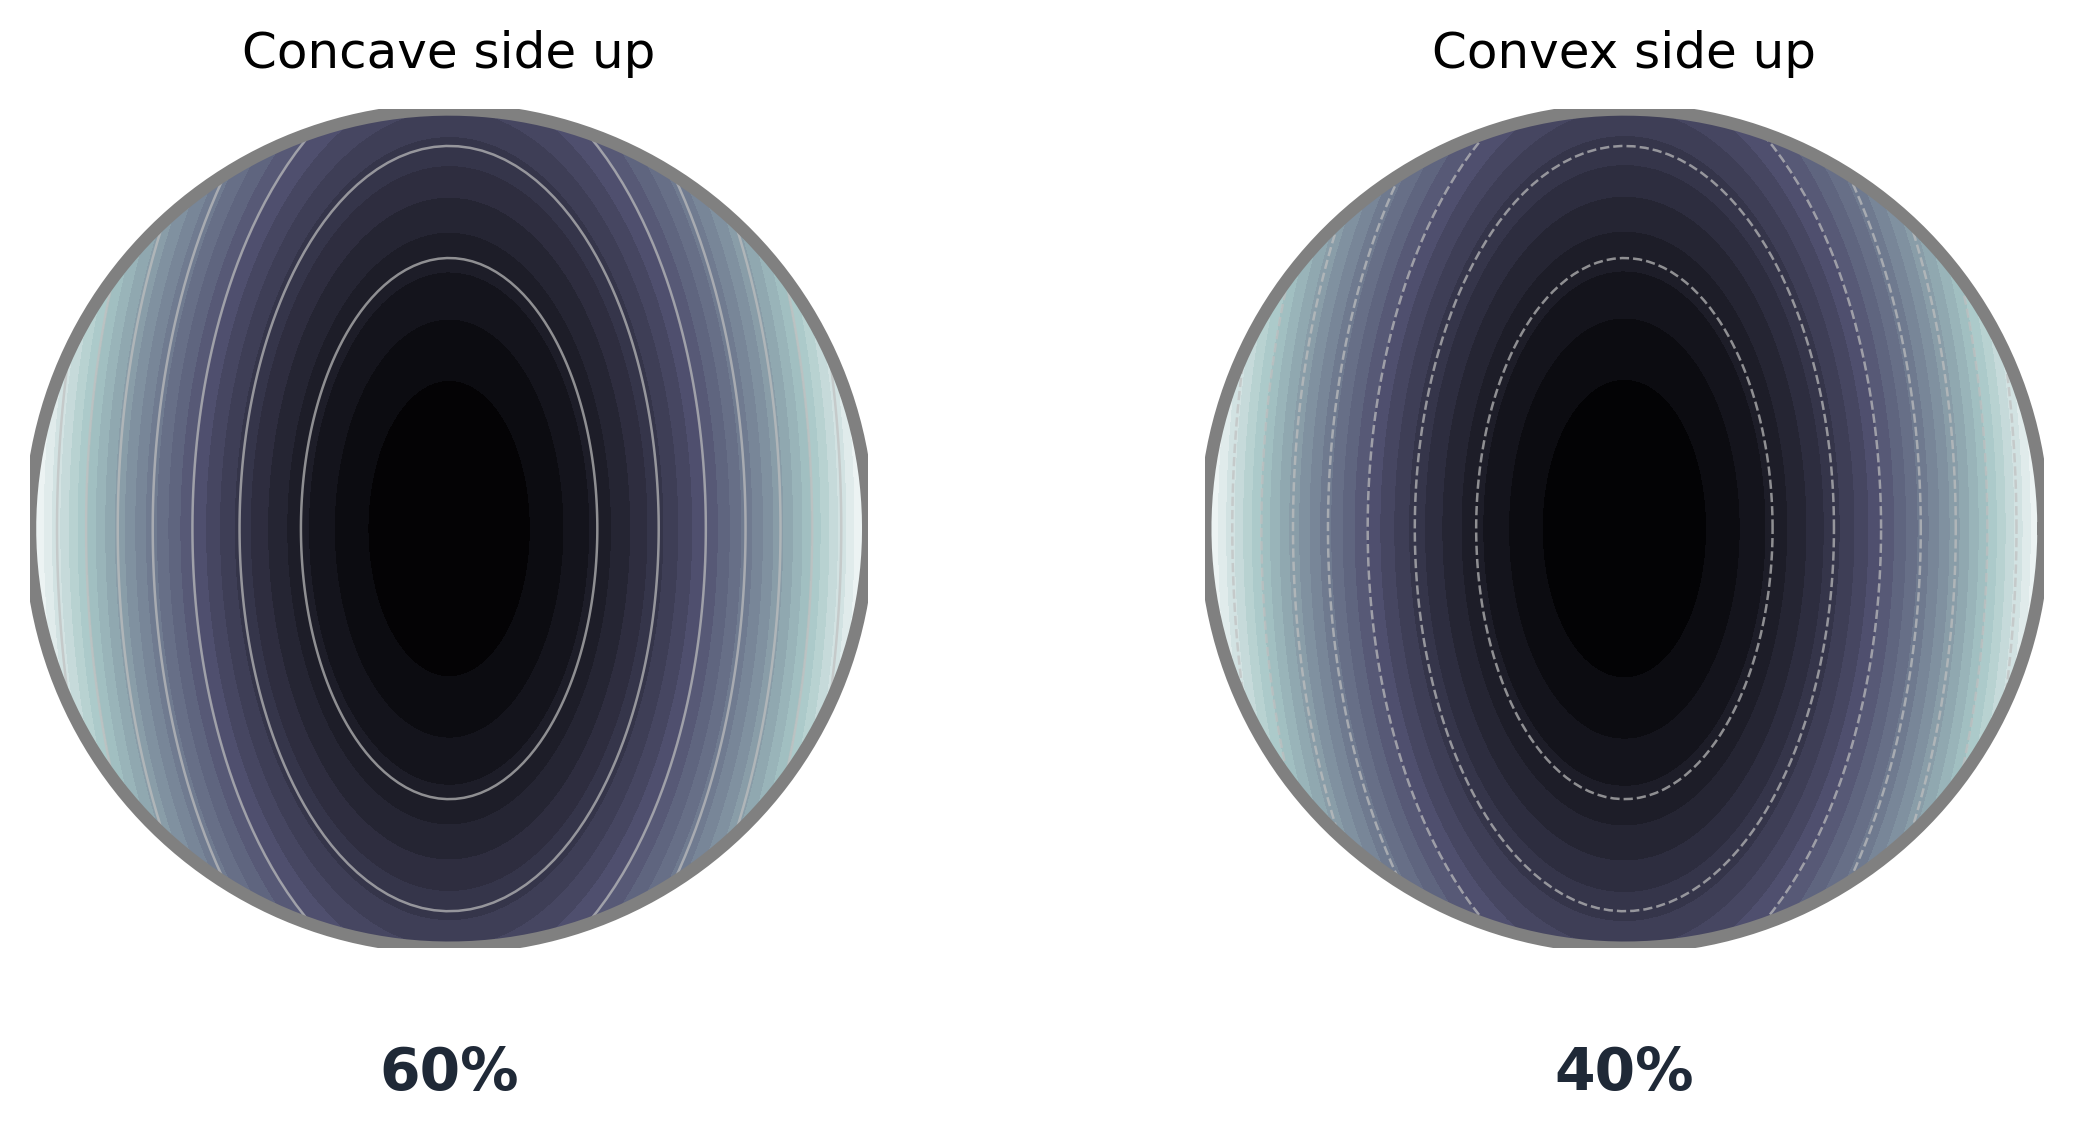

In [3]:
# Figure 2.2: 曲がったコインの可視化
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8), dpi=300)

theta = np.linspace(0, 2 * np.pi, 200)
r = np.linspace(0, 1, 100)
R, THETA = np.meshgrid(r, theta)
X = R * np.cos(THETA)
Y = R * np.sin(THETA)

# Left: Concave side up (60%)
Z_concave = 0.4 * (X**2 + 0.3 * Y**2)
axes[0].contourf(X, Y, Z_concave, levels=30, cmap='bone')
axes[0].contour(X, Y, Z_concave, levels=8, colors='silver', linewidths=0.6, alpha=0.7)
axes[0].plot(np.cos(theta), np.sin(theta), color='gray', linewidth=3)
axes[0].set_aspect('equal')
axes[0].axis('off')
axes[0].set_title("Concave side up", fontsize=12, pad=10)
axes[0].text(0.5, -0.15, "60%", transform=axes[0].transAxes,
             ha='center', va='center', fontsize=14, fontweight='bold', color='#1f2937')

# Right: Convex side up (40%)
Z_convex = -Z_concave
axes[1].contourf(X, Y, Z_convex, levels=30, cmap='bone_r')
axes[1].contour(X, Y, Z_convex, levels=8, colors='silver', linewidths=0.6, alpha=0.7)
axes[1].plot(np.cos(theta), np.sin(theta), color='gray', linewidth=3)
axes[1].set_aspect('equal')
axes[1].axis('off')
axes[1].set_title("Convex side up", fontsize=12, pad=10)
axes[1].text(0.5, -0.15, "40%", transform=axes[1].transAxes,
             ha='center', va='center', fontsize=14, fontweight='bold', color='#1f2937')

plt.tight_layout()
save_plot(fig, "result/fig2_02_bent_coin.png")
save_plot(fig, "../result/fig2_02_bent_coin.png")
plt.show()

#### 実験結果の分析・考察: Figure 2.2
- コインの物理的非対称性により、反復試行の頻度極限として凹面上向き $60\%$, 凸面上向き $40\%$ という客観的な確率（頻度）が得られます。
- 深層学習において、モデルパラメータ $W$ を「真の固定値だがデータから推定すべきもの」と捉えるのが頻度論（最尤推定）、パラメータ自身を「不確実性を持つ確率変数」として事前分布 $p(W)$ と事後分布 $p(W|D)$ で扱うのがベイズ的アプローチです。
- 重要なのは、**解釈が頻度主義であろうとベイズ主義であろうと、確率が満たすべき数学的規則（加法定理・乗法定理・ベイズの定理）は全く同一である** という点です。

---

<a id="sec_2_1_1"></a>
### 2.1.1 A medical screening example

確率論の重要性を実感するために、教科書で提示される代表的な医療スクリーニング（がん検査）の具体例を考察します。

#### 問題設定
ある母集団において、無作為に選ばれた人が特定のがん（Cancer, $C=1$）に罹患している割合は $1\%$ であるとします：
$$p(C = 1) = 0.01, \quad p(C = 0) = 0.99$$

このがんを検出するためのスクリーニング検査（Test, $T \in \{0, 1\}$）があり、その診断特性は以下の通りです：
- **感度 (Sensitivity / True Positive Rate)**:
  がんに罹患している人が検査を受けたとき、正しく陽性と判定される確率は $90\%$ です。
  $$p(T = 1 \mid C = 1) = 0.90 \implies p(T = 0 \mid C = 1) = 0.10 	ext{ (偽陰性率)}$$
- **偽陽性率 (False Positive Rate)**:
  がんに罹患していない健康な人が検査を受けたとき、誤って陽性と判定されてしまう確率は $3\%$ です。
  $$p(T = 1 \mid C = 0) = 0.03 \implies p(T = 0 \mid C = 0) = 0.97 	ext{ (特異度)}$$

#### Figure 2.3: 検査精度のピクトグラム表示
この状況を直感的に表したものが以下の図です：
- 左側: がんに罹患していない健康な人 100 人中、97 人は正しく陰性（青）、3 人は誤って陽性（赤）。
- 右側: がんに罹患している患者 100 人中、10 人は誤って陰性（青）、90 人は正しく陽性（赤）。


Figure saved successfully to: result/fig2_03_medical_screening.png
Figure saved successfully to: ../result/fig2_03_medical_screening.png


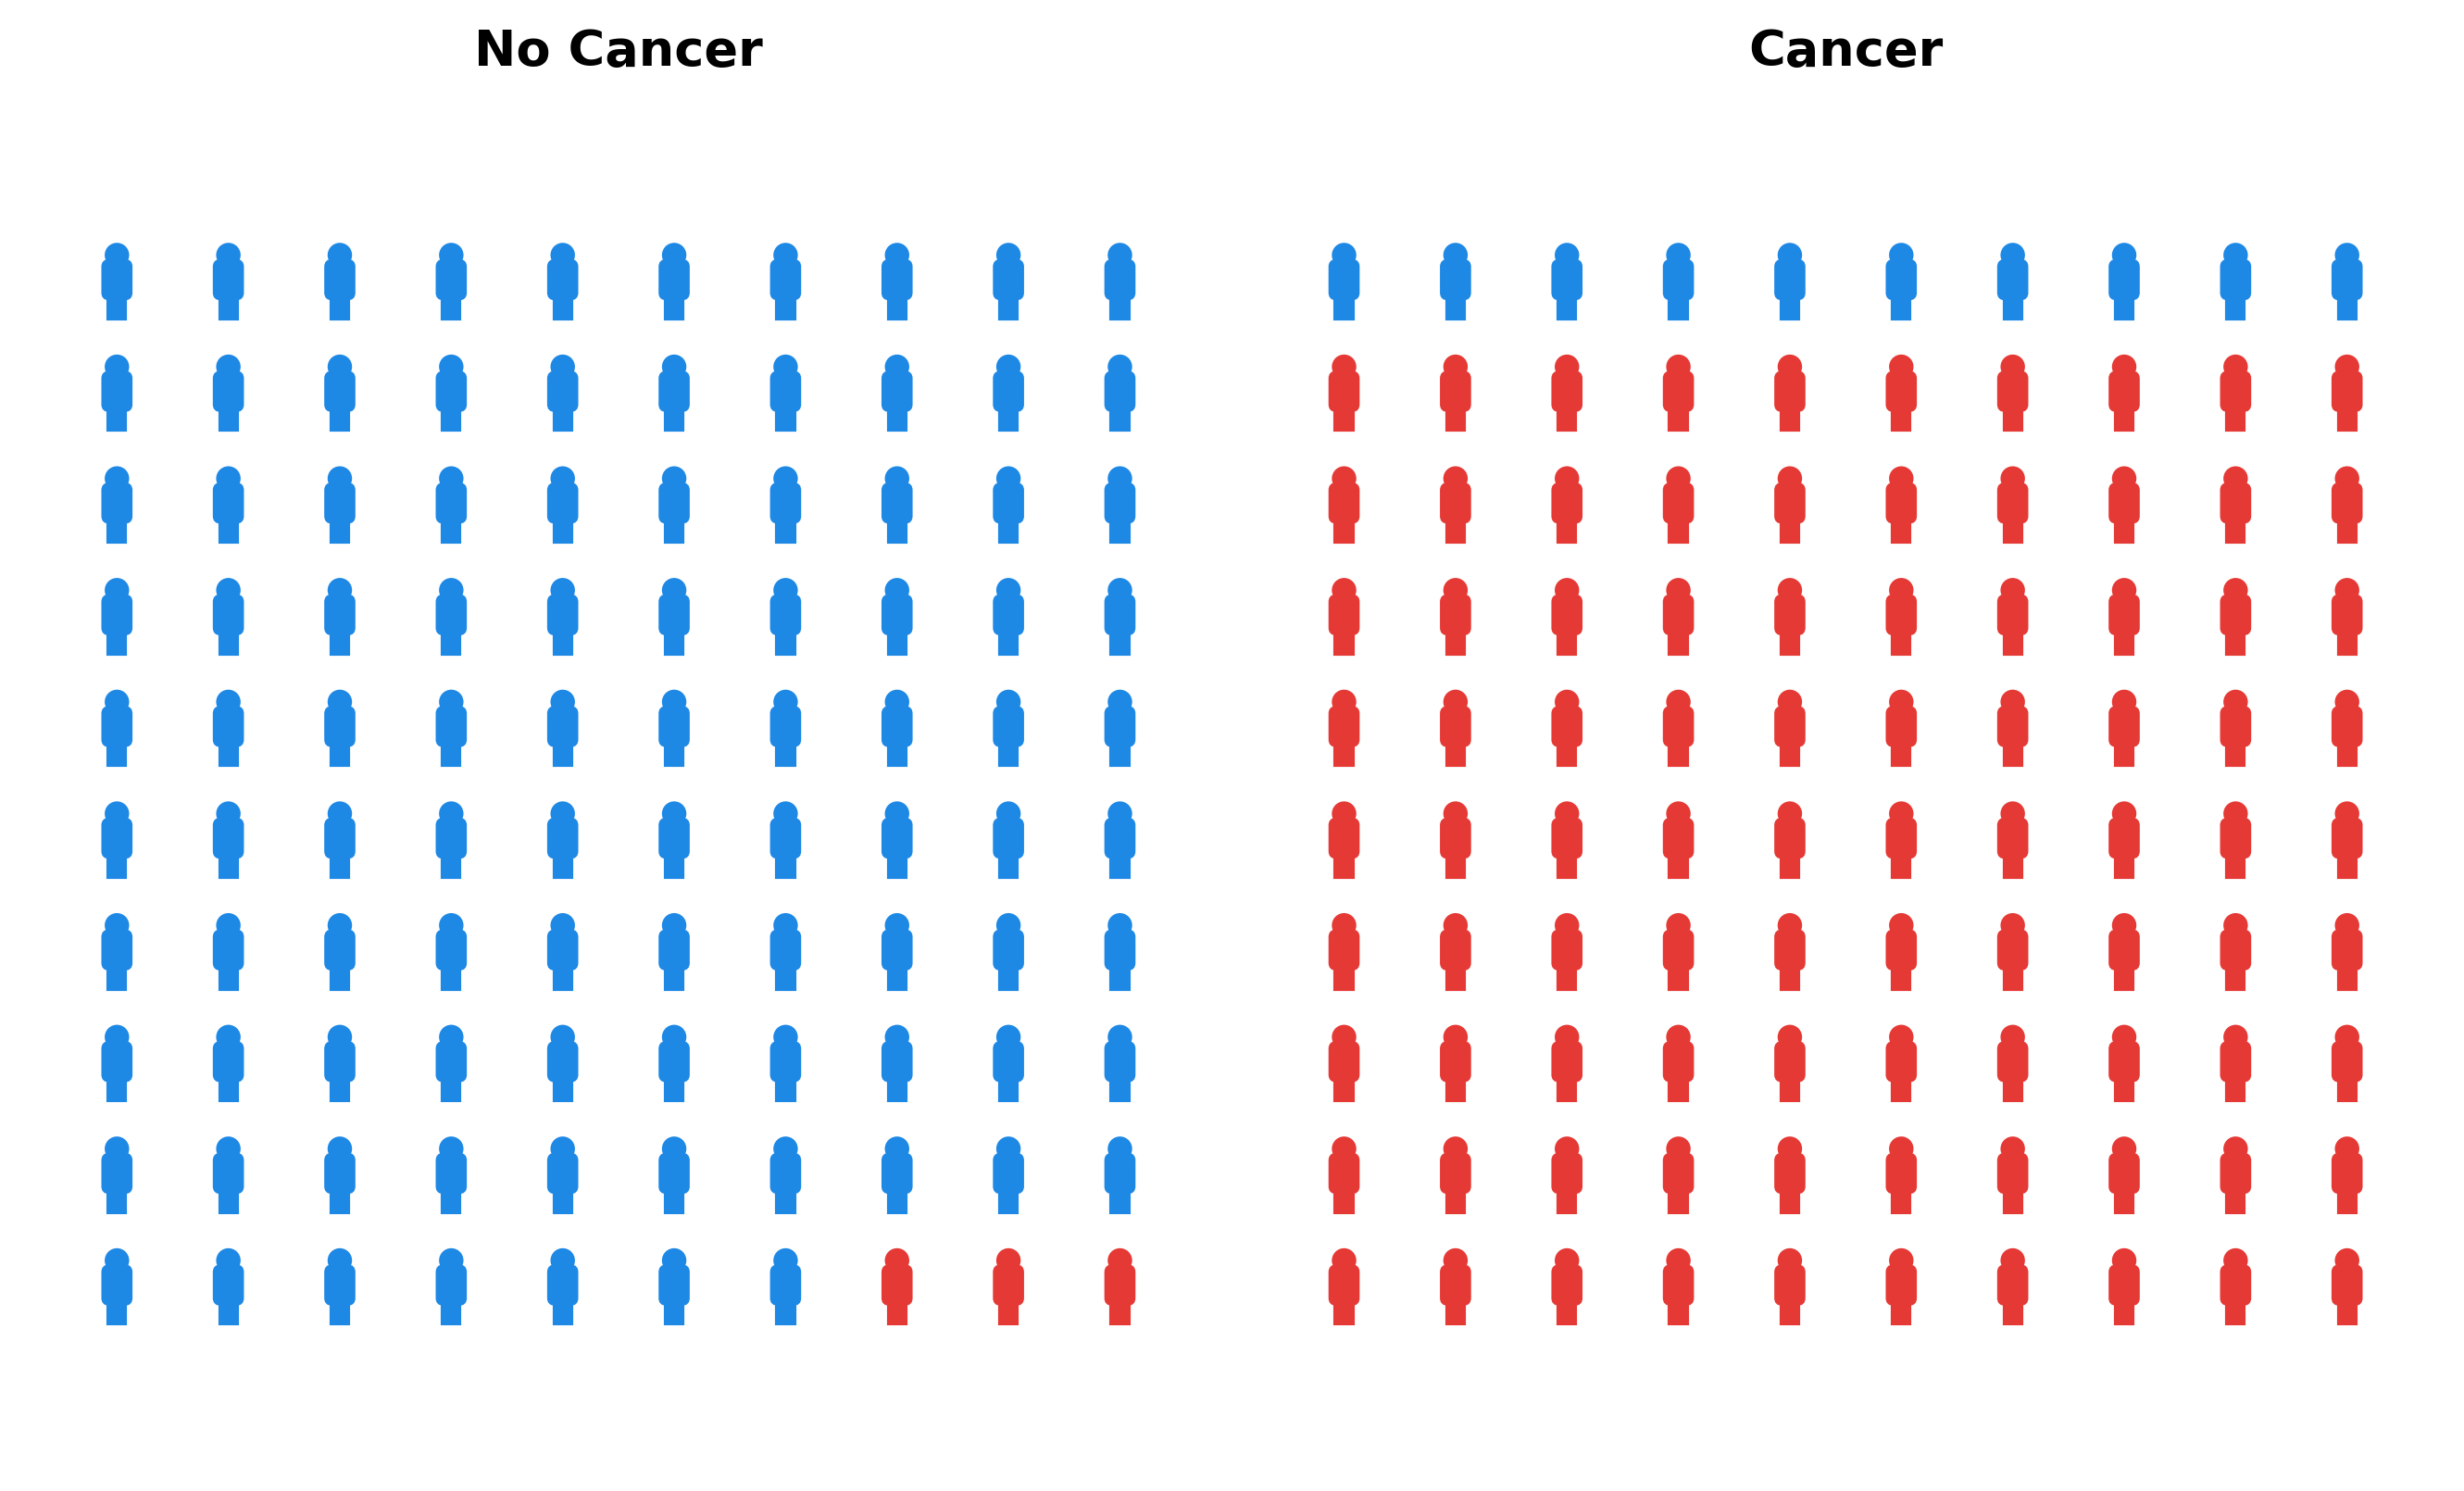

In [4]:
# Figure 2.3: 医療スクリーニング精度のピクトグラム
def draw_person_icon(ax, x, y, color, scale=0.42):
    head = patches.Circle((x, y + scale * 0.75), scale * 0.22, color=color, zorder=3)
    ax.add_patch(head)
    body = patches.FancyBboxPatch(
        (x - scale * 0.22, y - scale * 0.1),
        scale * 0.44, scale * 0.65,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        color=color, zorder=3
    )
    ax.add_patch(body)
    leg1 = patches.Rectangle((x - scale * 0.18, y - scale * 0.6), scale * 0.14, scale * 0.55, color=color, zorder=3)
    leg2 = patches.Rectangle((x + scale * 0.04, y - scale * 0.6), scale * 0.14, scale * 0.55, color=color, zorder=3)
    ax.add_patch(leg1)
    ax.add_patch(leg2)

fig, axes = plt.subplots(1, 2, figsize=(9, 5.5), dpi=300)
c_blue, c_red = '#1e88e5', '#e53935'

# No Cancer (100 people: 97 blue, 3 red at bottom right)
ax_left = axes[0]
ax_left.set_xlim(-0.8, 9.8)
ax_left.set_ylim(-1.5, 10.5)
ax_left.axis('off')
ax_left.set_title("No Cancer", fontsize=13, fontweight='bold', pad=15)

for row in range(10):
    for col in range(10):
        color = c_red if (row == 0 and col >= 7) else c_blue
        draw_person_icon(ax_left, col, row, color)

# Cancer (100 people: 10 blue at top, 90 red)
ax_right = axes[1]
ax_right.set_xlim(-0.8, 9.8)
ax_right.set_ylim(-1.5, 10.5)
ax_right.axis('off')
ax_right.set_title("Cancer", fontsize=13, fontweight='bold', pad=15)

for row in range(10):
    for col in range(10):
        color = c_blue if (row == 9) else c_red
        draw_person_icon(ax_right, col, row, color)

plt.tight_layout()
save_plot(fig, "result/fig2_03_medical_screening.png")
save_plot(fig, "../result/fig2_03_medical_screening.png")
plt.show()

#### 実験結果の分析・考察: Figure 2.3
- この図を見ると、検査は「がん患者の90%を検出し、健常者の97%を正しく陰性と判定する」ため、一見すると非常に高精度で信頼できるように思われます。
- ここで、2つの極めて実践的な問いが生じます：
  1. **問い1**: 母集団から任意に選んだ人が検査を受けたとき、検査結果が「陽性」となる全体確率 $p(T=1)$ はいくつか？
  2. **問い2**: ある人が検査を受けて「陽性」と判定された場合、その人が**実際にがんに罹患している事後確率 $p(C=1 \mid T=1)$** はいくつか？多くの人は「90%くらい」と直感的に答えがちですが、実際はどうでしょうか？
- この2つの問いに厳密に答えるためには、次に学ぶ **確率の基本規則（加法定理・乗法定理・ベイズの定理）** が不可欠となります。

---

<a id="sec_2_1_2"></a>
### 2.1.2 The sum and product rules

確率のあらゆる定理の根幹をなす2つの基本規則を、幾何学的・度数論的モデルから導出します。

#### 離散度数グリッドモデル (Figure 2.4)
2つの離散確率変数 $X, Y$ を考えます：
- $X$ は $L$ 個の離散値 $\{x_i\}$ ($i = 1, \dots, L$) をとる。
- $Y$ は $M$ 個の離散値 $\{y_j\}$ ($j = 1, \dots, M$) をとる。

合計 $N$ 回の独立な試行を行い、事象 $(X = x_i, Y = y_j)$ が同時に観測された回数を $n_{ij}$ とします。
- 列 $i$（$X = x_i$）の合計度数: $c_i = \sum_{j=1}^M n_{ij}$
- 行 $j$（$Y = y_j$）の合計度数: $r_j = \sum_{i=1}^L n_{ij}$
- 全度数の総和: $\sum_{i=1}^L c_i = \sum_{j=1}^M r_j = \sum_{i=1}^L \sum_{j=1}^M n_{ij} = N$


Figure saved successfully to: result/fig2_04_sum_product_rules.png
Figure saved successfully to: ../result/fig2_04_sum_product_rules.png


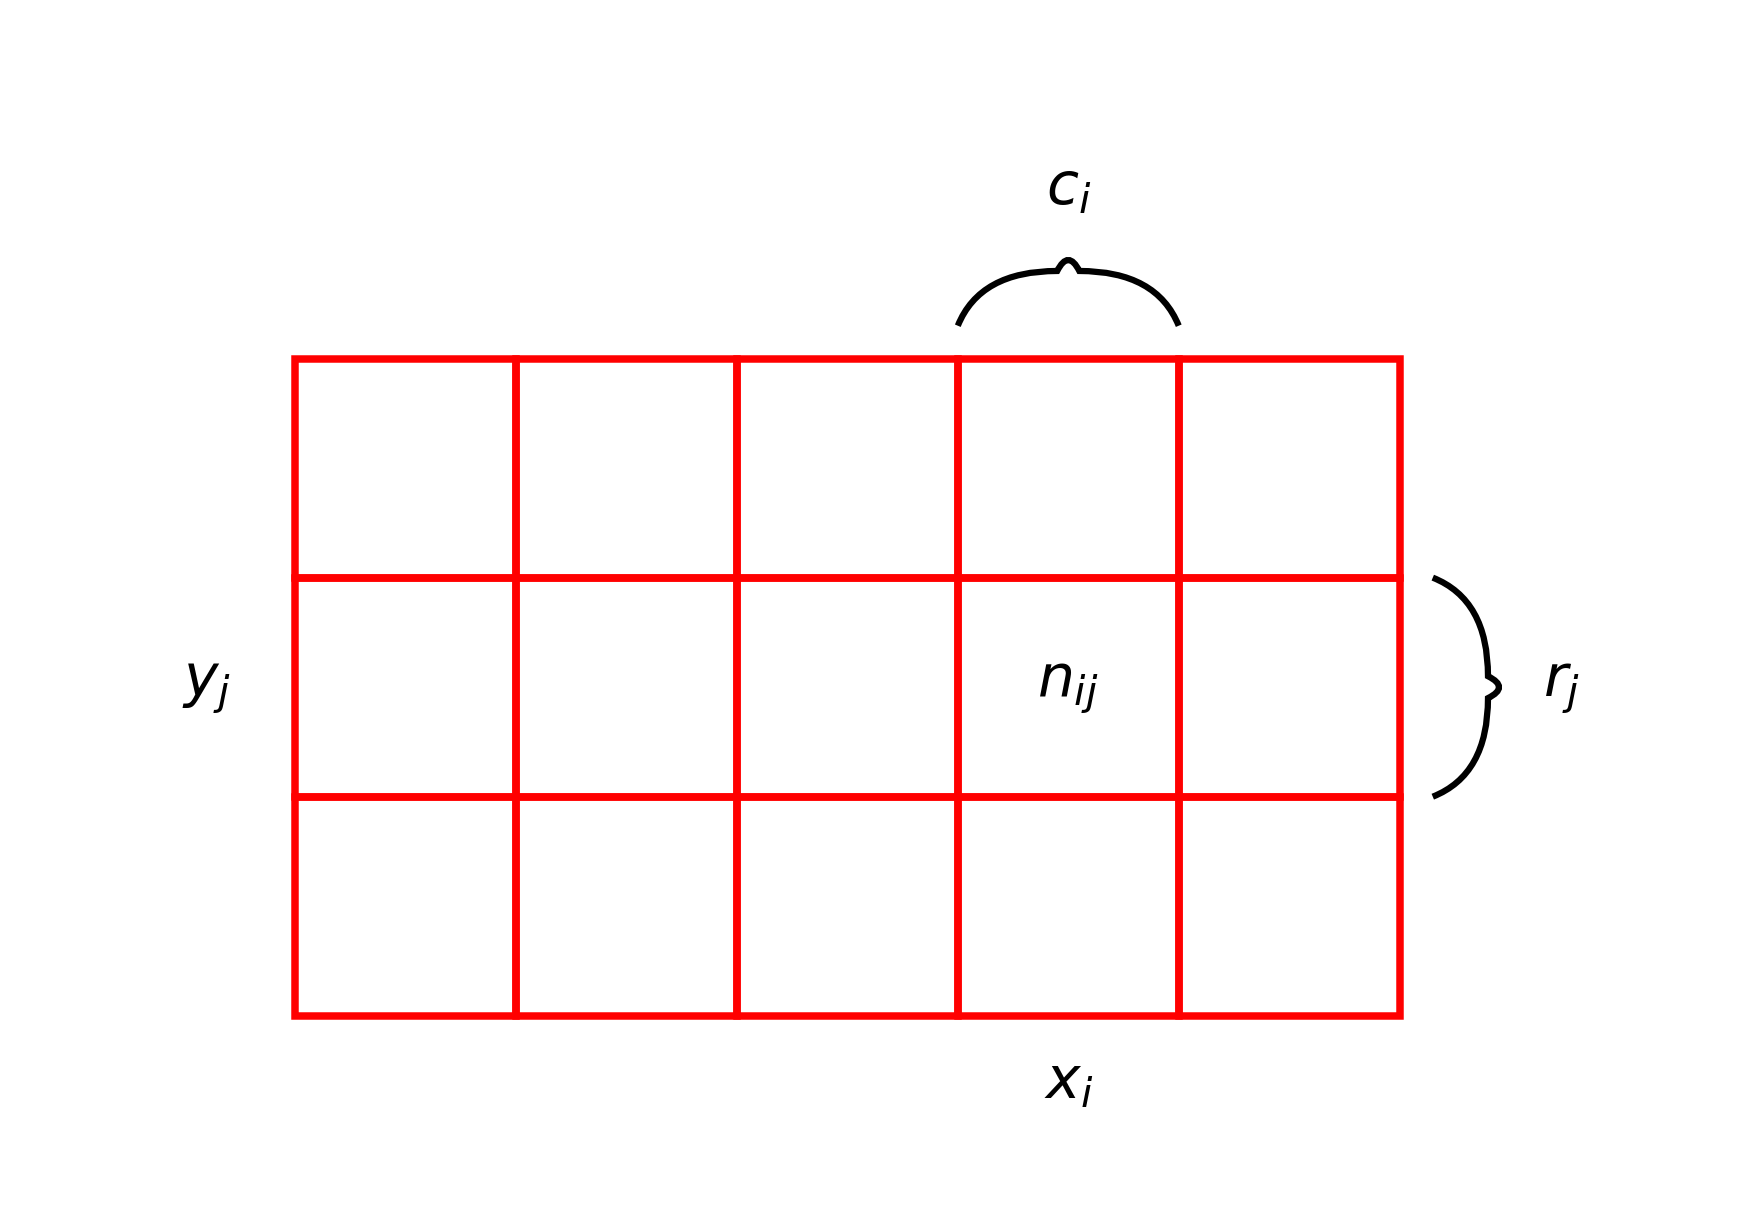

In [5]:
# Figure 2.4: 加法定理・乗法定理の格子セルモデル描画
fig, ax = plt.subplots(figsize=(6, 4.2), dpi=300)
ax.set_xlim(-1.2, 6.5)
ax.set_ylim(-0.8, 4.5)
ax.axis('off')

cols, rows = 5, 3
for c in range(cols):
    for r in range(rows):
        rect = patches.Rectangle((c, r), 1, 1, fill=False, edgecolor='red', linewidth=1.8)
        ax.add_patch(rect)

target_c, target_r = 3, 1
ax.text(target_c + 0.5, target_r + 0.5, r'$n_{ij}$', ha='center', va='center', fontsize=14, fontstyle='italic')
ax.text(target_c + 0.5, -0.3, r'$x_i$', ha='center', va='center', fontsize=14, fontstyle='italic')
ax.text(-0.4, target_r + 0.5, r'$y_j$', ha='center', va='center', fontsize=14, fontstyle='italic')

# Top bracket for c_i
bx0, bx1 = target_c, target_c + 1.0
by, bh = rows + 0.15, 0.25
bm = (bx0 + bx1) / 2.0
verts_top = [
    (bx0, by), (bx0 + 0.1, by + bh), (bm - 0.05, by + bh),
    (bm, by + bh + 0.1),
    (bm + 0.05, by + bh), (bx1 - 0.1, by + bh), (bx1, by)
]
codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3, Path.CURVE3, Path.CURVE3, Path.CURVE3, Path.CURVE3]
ax.add_patch(patches.PathPatch(Path(verts_top, codes), facecolor='none', edgecolor='black', lw=1.5))
ax.text(bm, by + bh + 0.25, r'$c_i$', ha='center', va='bottom', fontsize=14, fontstyle='italic')

# Right bracket for r_j
ry0, ry1 = target_r, target_r + 1.0
rx, rw = cols + 0.15, 0.25
rm = (ry0 + ry1) / 2.0
verts_right = [
    (rx, ry0), (rx + rw, ry0 + 0.1), (rx + rw, rm - 0.05),
    (rx + rw + 0.1, rm),
    (rx + rw, rm + 0.05), (rx + rw, ry1 - 0.1), (rx, ry1)
]
ax.add_patch(patches.PathPatch(Path(verts_right, codes), facecolor='none', edgecolor='black', lw=1.5))
ax.text(rx + rw + 0.25, rm, r'$r_j$', ha='left', va='center', fontsize=14, fontstyle='italic')

plt.tight_layout()
save_plot(fig, "result/fig2_04_sum_product_rules.png")
save_plot(fig, "../result/fig2_04_sum_product_rules.png")
plt.show()

#### 数式による厳密な導出

##### 1. 同時確率 (Joint Probability)
$X = x_i$ かつ $Y = y_j$ である事象の確率は、全試行数 $N$ に対するセル $(i, j)$ の度数の割合の極限（$N 	o \infty$）として定義されます：
$$p(X = x_i, Y = y_j) = rac{n_{ij}}{N} 	ag{2.1}$$

##### 2. 周辺確率 (Marginal Probability)
$Y$ の値にかかわらず、$X = x_i$ である確率は列 $i$ に入る全度数 $c_i$ の割合です：
$$p(X = x_i) = rac{c_i}{N} 	ag{2.2}$$
$\sum_{i=1}^L c_i = N$ より、確率の総和が 1 になる正規化条件が直ちに導かれます：
$$\sum_{i=1}^L p(X = x_i) = \sum_{i=1}^L rac{c_i}{N} = rac{N}{N} = 1 	ag{2.3}$$

##### 3. 加法定理 (The Sum Rule)
列 $i$ の総和は $c_i = \sum_{j=1}^M n_{ij}$ であるため、式(2.2)に代入して：
$$p(X = x_i) = rac{c_i}{N} = rac{\sum_{j=1}^M n_{ij}}{N} = \sum_{j=1}^M rac{n_{ij}}{N} = \sum_{j=1}^M p(X = x_i, Y = y_j) 	ag{2.4}$$
これが **確率の加法定理 (The Sum Rule of Probability)** です。不要な変数（ここでは $Y$）について足し合わせる操作を **周辺化 (marginalization)** と呼びます。

##### 4. 条件付き確率 (Conditional Probability)
$X = x_i$ であることが既に分かっている（条件づけられた）という前提のもとで、$Y = y_j$ となる確率は、列 $i$ の度数 $c_i$ の中でセル $(i, j)$ の度数 $n_{ij}$ が占める割合です：
$$p(Y = y_j \mid X = x_i) = rac{n_{ij}}{c_i} 	ag{2.5}$$
両辺を $j$ について足し合わせると、$\sum_{j=1}^M n_{ij} = c_i$ より：
$$\sum_{j=1}^M p(Y = y_j \mid X = x_i) = rac{\sum_{j=1}^M n_{ij}}{c_i} = rac{c_i}{c_i} = 1 	ag{2.6}$$
条件付き確率もまた、それ自身が正規化された有効な確率分布をなします。

##### 5. 乗法定理 (The Product Rule)
式(2.1)の同時確率を変形すると：
$$p(X = x_i, Y = y_j) = rac{n_{ij}}{N} = rac{n_{ij}}{c_i} \cdot rac{c_i}{N} = p(Y = y_j \mid X = x_i) p(X = x_i) 	ag{2.7}$$
これが **確率の乗法定理 (The Product Rule of Probability)** です。

##### 6. コンパクト表記 (Compact Notation)
確率論では、特定の実現値 $x_i, y_j$ への言及を省略して、分布そのものを表す以下の簡潔な表記が広く用いられます：
$$	ext{加法定理: } p(X) = \sum_Y p(X, Y) 	ag{2.8}$$
$$	ext{乗法定理: } p(X, Y) = p(Y \mid X) p(X) 	ag{2.9}$$
対称性により、$p(X, Y) = p(X \mid Y) p(Y)$ も成り立ちます。


#### Figure 2.5: 同時分布・周辺分布・条件付き分布の数値シミュレーション
9個の離散値をとる変数 $X \in \{1, \dots, 9\}$ と、2値をとる変数 $Y \in \{1, 2\}$ について、$N = 60$ 個の有限サンプルデータを生成し、同時分布、周辺分布、条件付き分布のヒストグラム推定を可視化します。


Total points N = 60


Figure saved successfully to: result/fig2_05_joint_marginal_conditional.png


Figure saved successfully to: ../result/fig2_05_joint_marginal_conditional.png


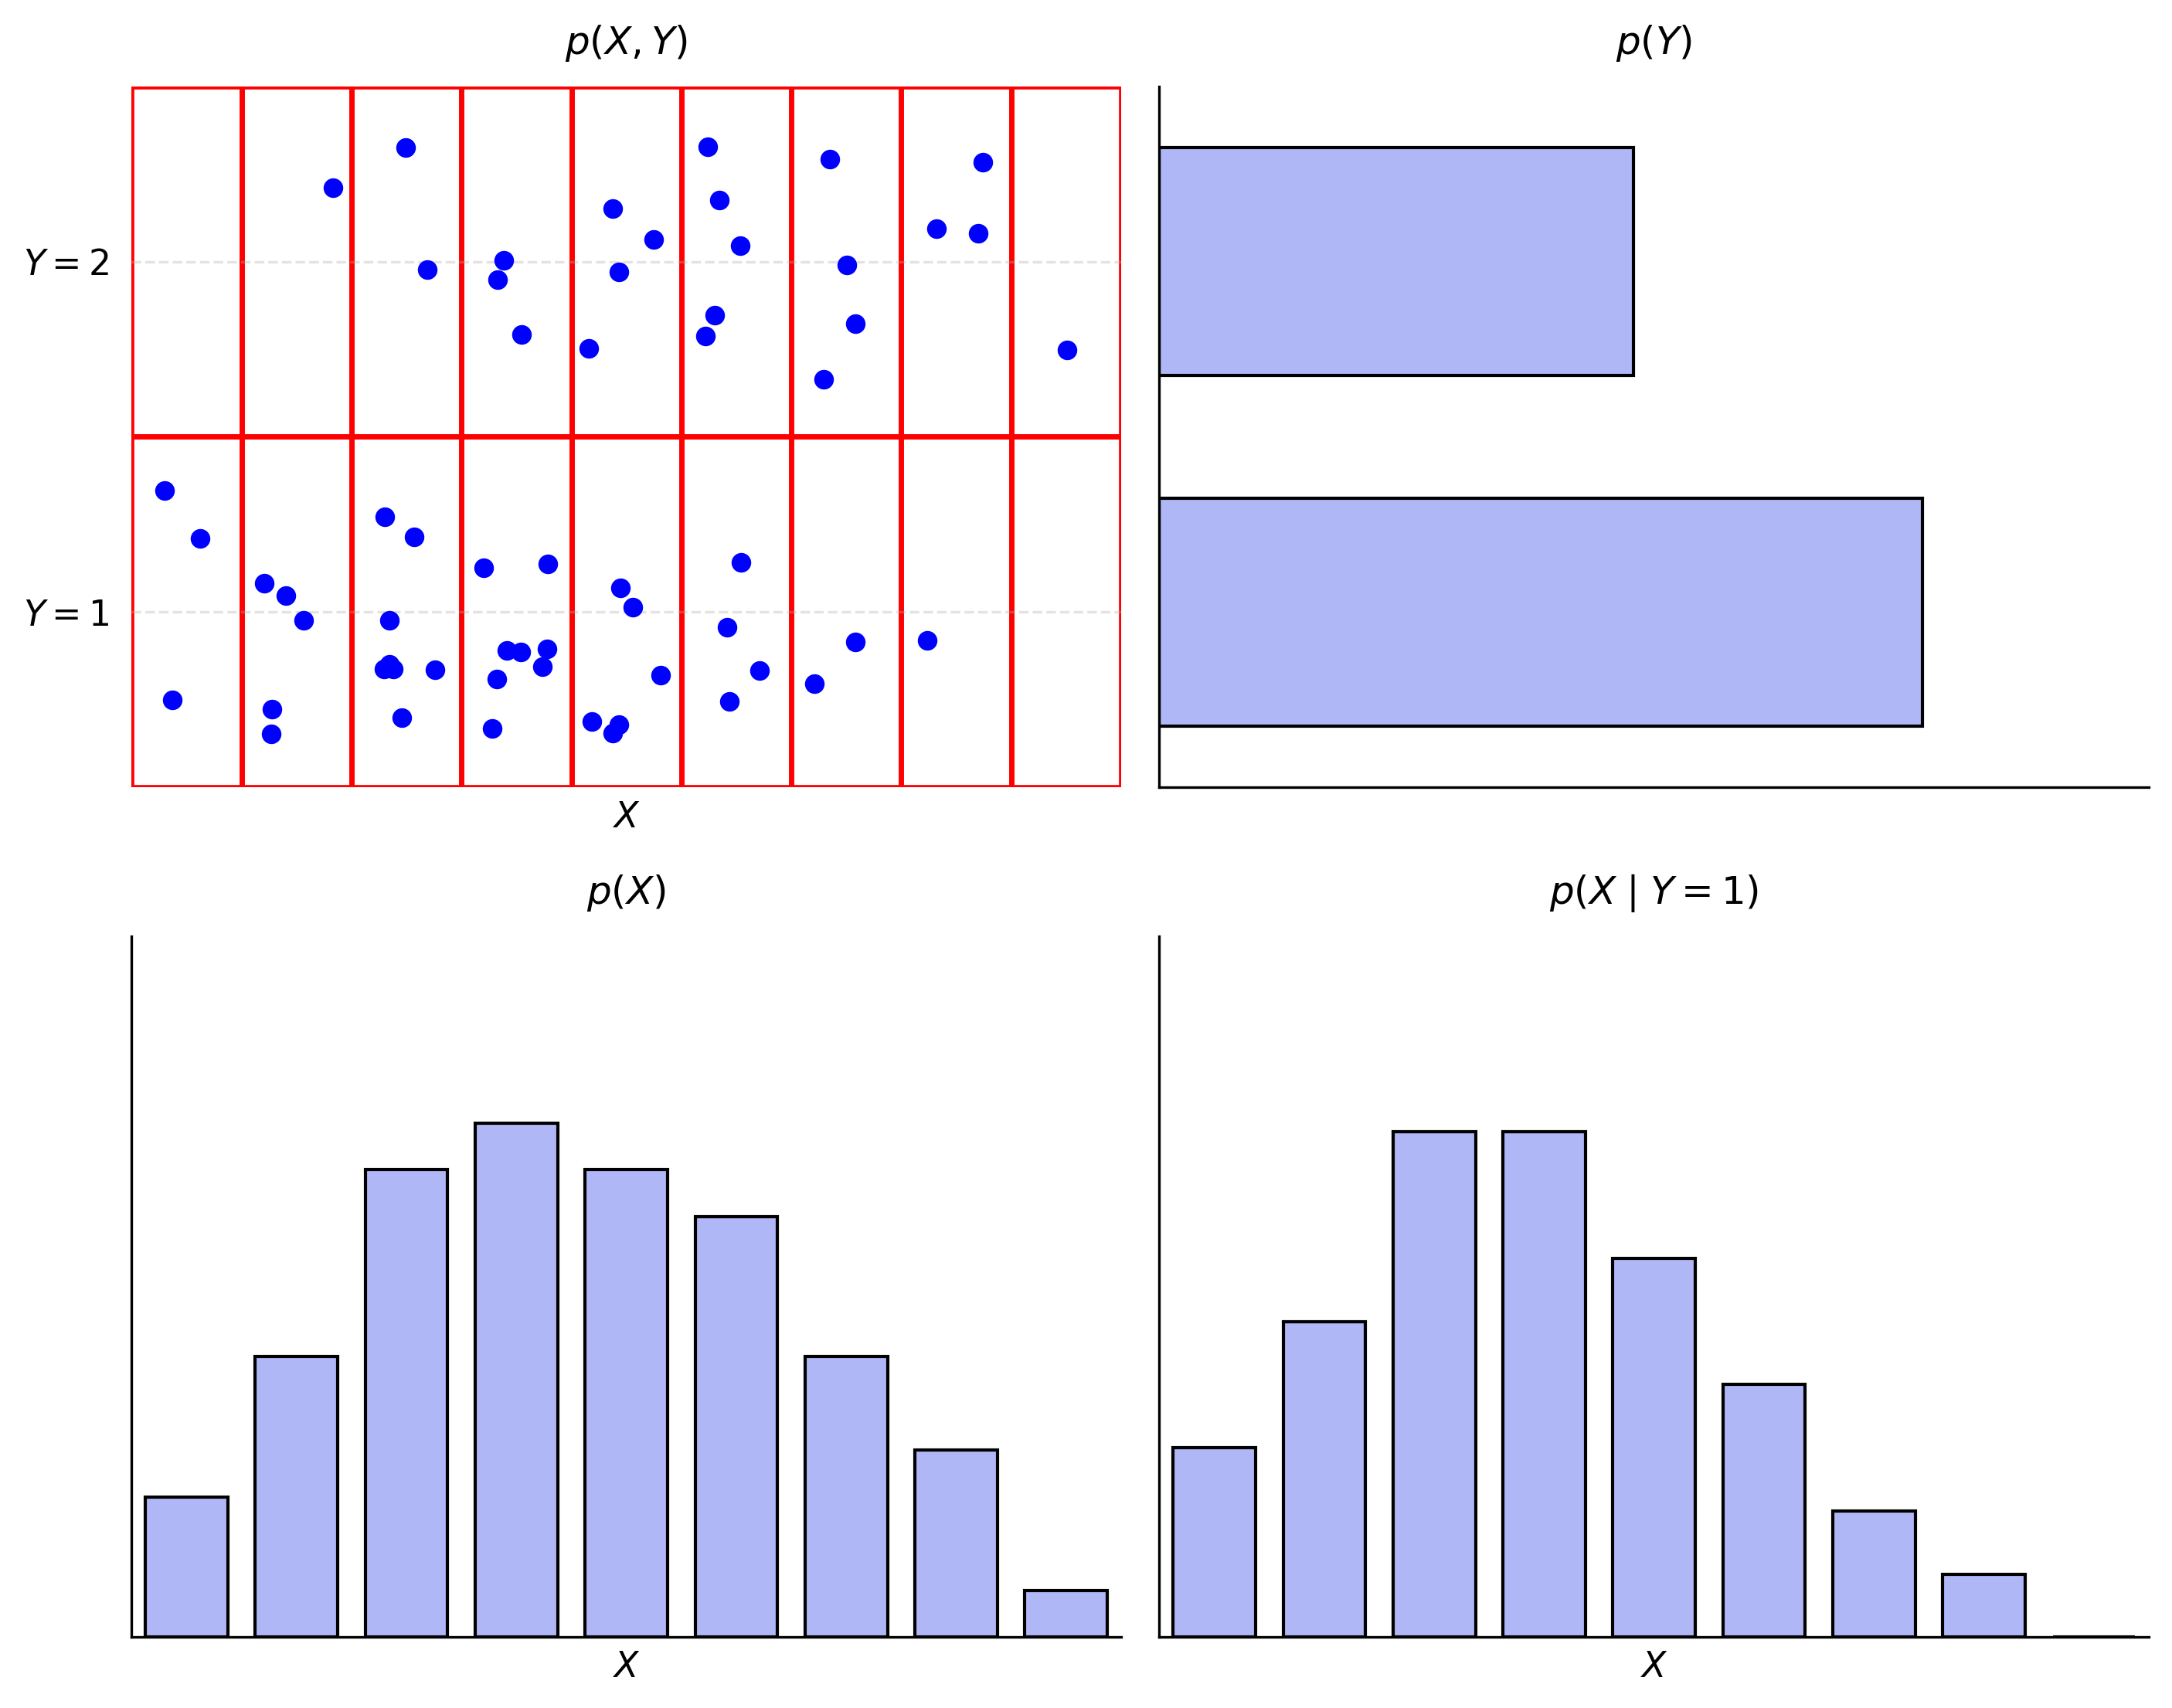

In [6]:
# Figure 2.5: 同時分布、周辺分布、条件付き分布のヒストグラム推定
counts_y1 = np.array([3, 5, 8, 8, 6, 4, 2, 1, 0])  # Y = 1, sum = 37
counts_y2 = np.array([0, 1, 2, 3, 4, 5, 4, 3, 1])  # Y = 2, sum = 23
nij_60 = np.column_stack([counts_y1, counts_y2])   # shape (9, 2)
N = int(np.sum(nij_60))
print(f"Total points N = {N}")

res_prob = compute_joint_marginal_conditional(nij_60)
p_X = res_prob["p_X"]
p_Y = res_prob["p_Y"]
p_X_given_Y1 = res_prob["p_XY"][:, 0] / np.sum(res_prob["p_XY"][:, 0])

fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.5), dpi=300)
rng = np.random.default_rng(2024)

# Top-Left: p(X, Y)
ax_tl = axes[0, 0]
ax_tl.set_xlim(0, 9)
ax_tl.set_ylim(0, 2)
for c in range(9):
    for r in range(2):
        ax_tl.add_patch(patches.Rectangle((c, r), 1, 1, fill=False, edgecolor='red', linewidth=1.6))
        
for c in range(9):
    n1 = counts_y1[c]
    if n1 > 0:
        ax_tl.scatter(rng.uniform(c + 0.15, c + 0.85, n1), rng.uniform(0.15, 0.85, n1), color='blue', s=26, zorder=3)
    n2 = counts_y2[c]
    if n2 > 0:
        ax_tl.scatter(rng.uniform(c + 0.15, c + 0.85, n2), rng.uniform(1.15, 1.85, n2), color='blue', s=26, zorder=3)

ax_tl.set_title(r'$p(X, Y)$', fontsize=12, pad=10)
ax_tl.set_xlabel(r'$X$', fontsize=11)
ax_tl.set_yticks([0.5, 1.5])
ax_tl.set_yticklabels([r'$Y = 1$', r'$Y = 2$'], fontsize=11)
ax_tl.set_xticks([])
ax_tl.tick_params(left=False)
for s in ax_tl.spines.values(): s.set_visible(False)

# Top-Right: p(Y)
ax_tr = axes[0, 1]
ax_tr.barh([0.5, 1.5], [p_Y[0], p_Y[1]], height=0.65, color='#b0b7f7', edgecolor='black', linewidth=1.0)
ax_tr.set_title(r'$p(Y)$', fontsize=12, pad=10)
ax_tr.set_ylim(0, 2)
ax_tr.set_xlim(0, 0.8)
ax_tr.set_xticks([])
ax_tr.set_yticks([])

# Bottom-Left: p(X)
ax_bl = axes[1, 0]
x_pos = np.arange(9) + 0.5
ax_bl.bar(x_pos, p_X, width=0.75, color='#b0b7f7', edgecolor='black', linewidth=1.0)
ax_bl.set_title(r'$p(X)$', fontsize=12, pad=10)
ax_bl.set_xlabel(r'$X$', fontsize=11)
ax_bl.set_xlim(0, 9)
ax_bl.set_ylim(0, 0.25)
ax_bl.set_xticks([])
ax_bl.set_yticks([])

# Bottom-Right: p(X | Y = 1)
ax_br = axes[1, 1]
ax_br.bar(x_pos, p_X_given_Y1, width=0.75, color='#b0b7f7', edgecolor='black', linewidth=1.0)
ax_br.set_title(r'$p(X \mid Y = 1)$', fontsize=12, pad=10)
ax_br.set_xlabel(r'$X$', fontsize=11)
ax_br.set_xlim(0, 9)
ax_br.set_ylim(0, 0.30)
ax_br.set_xticks([])
ax_br.set_yticks([])

plt.tight_layout()
save_plot(fig, "result/fig2_05_joint_marginal_conditional.png")
save_plot(fig, "../result/fig2_05_joint_marginal_conditional.png")
plt.show()

#### 実験結果の分析・考察: Figure 2.5
- **左上 $p(X, Y)$**: 2次元空間におけるデータ点の同時分布です。下段 ($Y=1$) は左〜中央寄りに点が多く、上段 ($Y=2$) は右寄りに点が多いことが視覚的に確認できます。
- **右上 $p(Y)$**: $X$ に関して足し合わせた周辺確率です。全60点中、$Y=1$ に37点（約 $61.7\%$）、$Y=2$ に23点（約 $38.3\%$）が存在します。
- **左下 $p(X)$**: $Y$ に関して足し合わせた周辺確率です。全データにおける $X$ の分布形状（中央値がやや左に寄った山型）が現れています。
- **右下 $p(X \mid Y=1)$**: $Y=1$（下段）に条件づけられた $X$ の条件付き確率です。全体分布 $p(X)$ と比較すると、右側の裾野がさらに小さくなり、より左寄りのピークが強調されています。

---

<a id="sec_2_1_3"></a>
### 2.1.3 Bayes’ theorem

加法定理と乗法定理というわずか2つの規則から、現代の統計学および機械学習で最も強力な定理である **ベイズの定理 (Bayes' Theorem)** を導出します。

#### 厳密な導出
同時確率の定義における対称性より：
$$p(X, Y) = p(Y, X)$$
乗法定理 式(2.9) を左右に適用すると：
$$p(Y \mid X) p(X) = p(X \mid Y) p(Y)$$
$p(X) > 0$ であるとき、両辺を $p(X)$ で割ることでベイズの定理が得られます：
$$p(Y \mid X) = rac{p(X \mid Y) p(Y)}{p(X)} 	ag{2.10}$$

さらに分母の $p(X)$ に対して加法定理 式(2.8) および乗法定理 式(2.9) を適用すると：
$$p(X) = \sum_Y p(X, Y) = \sum_Y p(X \mid Y) p(Y) 	ag{2.11}$$
したがって、ベイズの定理は次のように書くこともできます：
$$p(Y \mid X) = rac{p(X \mid Y) p(Y)}{\sum_{Y'} p(X \mid Y') p(Y')}$$

#### ベイズの定理の構成要素
機械学習の文脈において、各項は次のような重要な解釈を持ちます：
- **事前確率 (Prior probability) $p(Y)$**:
  データ $X$ を観測する前に私たちが持っている $Y$ に関する知識・信念。
- **尤度 (Likelihood) $p(X \mid Y)$**:
  ある仮説 $Y$ が真であるとしたときに、観測データ $X$ が得られる確率（もっともらしさ）。
- **周辺尤度 / 証拠 (Marginal likelihood / Evidence) $p(X)$**:
  すべての可能な仮説を重みづけ平均したデータ $X$ の発生確率。事後確率の総和を 1 にするための正規化定数（Normalization factor）。
- **事後確率 (Posterior probability) $p(Y \mid X)$**:
  データ $X$ を観測した後に更新された、$Y$ に関する新しい知識・信念。

$$	ext{事後確率 (Posterior)} \propto 	ext{尤度 (Likelihood)} 	imes 	ext{事前確率 (Prior)}$$


<a id="sec_2_1_4"></a>
### 2.1.4 Medical screening revisited

2.1.1節で提示した医療スクリーニングの課題に戻り、加法定理、乗法定理、ベイズの定理を用いて問い1・問い2を厳密に計算します。

#### 確率の定式化
- がんの有無を表す確率変数: $C \in \{0, 1\}$
  - $C = 1$: がんに罹患している (Cancer)
  - $C = 0$: がんに罹患していない (No cancer)
- 検査結果を表す確率変数: $T \in \{0, 1\}$
  - $T = 1$: 検査陽性 (Positive test)
  - $T = 0$: 検査陰性 (Negative test)

##### 事前確率 (Prior probabilities):
$$p(C = 1) = 0.01 	ag{2.12}$$
$$p(C = 0) = 1 - 0.01 = 0.99 	ag{2.13}$$

##### 条件付き確率（検査特性 / Likelihoods）:
$$p(T = 1 \mid C = 1) = 0.90 	ag{2.14}$$
$$p(T = 0 \mid C = 1) = 1 - 0.90 = 0.10 	ag{2.15}$$
$$p(T = 1 \mid C = 0) = 0.03 	ag{2.16}$$
$$p(T = 0 \mid C = 0) = 1 - 0.03 = 0.97 	ag{2.17}$$

条件付き確率は正規化条件を満たします：
$$\sum_{T \in \{0, 1\}} p(T \mid C = 1) = 0.90 + 0.10 = 1 	ag{2.18}$$
$$\sum_{T \in \{0, 1\}} p(T \mid C = 0) = 0.03 + 0.97 = 1 	ag{2.19}$$

---

#### 問い1の解決: 検査陽性となる全確率 $p(T = 1)$
加法定理 式(2.8) および 乗法定理 式(2.9) を適用します：
$$
\begin{aligned}
p(T = 1) &= \sum_{C \in \{0, 1\}} p(T = 1, C) \\
&= p(T = 1, C = 0) + p(T = 1, C = 1) \\
&= p(T = 1 \mid C = 0) p(C = 0) + p(T = 1 \mid C = 1) p(C = 1) \\
&= 0.03 	imes 0.99 + 0.90 	imes 0.01 \\
&= 0.0297 + 0.0090 \\
&= 0.0387 	ag{2.20}
\end{aligned}
$$
したがって、任意に受診した人が陽性判定を受ける確率は **約 $3.87\%$** です。

---

#### 問い2の解決: 陽性判定時に実際にがんに罹患している事後確率 $p(C = 1 \mid T = 1)$
ベイズの定理 式(2.10) を適用します：
$$
\begin{aligned}
p(C = 1 \mid T = 1) &= rac{p(T = 1 \mid C = 1) p(C = 1)}{p(T = 1)} 	ag{2.21} \\
&= rac{0.90 	imes 0.01}{0.0387} \\
&= rac{0.0090}{0.0387} = rac{90}{387} \\
&\approx 0.232558... \approx 23.3\% 	ag{2.22}
\end{aligned}
$$

陽性判定が出たとしても、実際にがんに罹患している確率は **わずか約 $23.3\%$** にすぎません！


In [7]:
# 医療スクリーニングの厳密計算コード
med_results = medical_screening_model(
    p_cancer=0.01,
    p_pos_given_cancer=0.90,
    p_pos_given_no_cancer=0.03
)

print("=== 医療スクリーニングモデルの計算結果 ===")
print(f"事前確率 p(C=1) [有病率]:             {med_results['p_cancer']:.4f}")
print(f"事前確率 p(C=0) [健常率]:             {med_results['p_no_cancer']:.4f}")
print(f"感度 p(T=1|C=1):                      {med_results['p_pos_given_cancer']:.4f}")
print(f"偽陰性率 p(T=0|C=1):                  {med_results['p_neg_given_cancer']:.4f}")
print(f"偽陽性率 p(T=1|C=0):                  {med_results['p_pos_given_no_cancer']:.4f}")
print(f"特異度 p(T=0|C=0):                    {med_results['p_neg_given_no_cancer']:.4f}")
print("------------------------------------------")
print(f"問い1: 全陽性確率 p(T=1) [式(2.20)]:   {med_results['p_pos']:.4f} ({med_results['p_pos']*100:.2f}%)")
print(f"問い2: 陽性時のがん事後確率 [式(2.22)]: {med_results['p_cancer_given_pos']:.6f} ({med_results['p_cancer_given_pos']*100:.2f}%)")
print(f"       陽性時の健常事後確率:          {med_results['p_no_cancer_given_pos']:.6f} ({med_results['p_no_cancer_given_pos']*100:.2f}%)")
print("------------------------------------------")
print(f"参考: 陰性時のがん事後確率 p(C=1|T=0): {med_results['p_cancer_given_neg']:.6f} ({med_results['p_cancer_given_neg']*100:.4f}%)")
print(f"      陰性時の健常事後確率 p(C=0|T=0): {med_results['p_no_cancer_given_neg']:.6f} ({med_results['p_no_cancer_given_neg']*100:.2f}%)")

=== 医療スクリーニングモデルの計算結果 ===
事前確率 p(C=1) [有病率]:             0.0100
事前確率 p(C=0) [健常率]:             0.9900
感度 p(T=1|C=1):                      0.9000
偽陰性率 p(T=0|C=1):                  0.1000
偽陽性率 p(T=1|C=0):                  0.0300
特異度 p(T=0|C=0):                    0.9700
------------------------------------------
問い1: 全陽性確率 p(T=1) [式(2.20)]:   0.0387 (3.87%)
問い2: 陽性時のがん事後確率 [式(2.22)]: 0.232558 (23.26%)
       陽性時の健常事後確率:          0.767442 (76.74%)
------------------------------------------
参考: 陰性時のがん事後確率 p(C=1|T=0): 0.001040 (0.1040%)
      陰性時の健常事後確率 p(C=0|T=0): 0.998960 (99.90%)


#### 10万人規模のシミュレーションによる直感的理解
抽象的な数式だけでなく、具体的な人数（100,000人）で考えると、この結果が極めて自然であることが分かります：

| 区分 | がん患者 ($C=1$, 1%) | 健常者 ($C=0$, 99%) | 合計 |
| :--- | :--- | :--- | :--- |
| **対象人数** | **1,000人** | **99,000人** | 100,000人 |
| **検査陽性 ($T=1$)** | **900人** (感度90%) | **2,970人** (偽陽性3%) | **3,870人** (式2.20) |
| **検査陰性 ($T=0$)** | 100人 (偽陰性10%) | 96,030人 (特異度97%) | 96,130人 |

陽性判定を受けた人は全体で $3,870$ 人います。そのうち実際にがんに罹患している人は $900$ 人だけです：
$$\frac{900}{3,870} = \frac{90}{387} \approx 23.26\%$$
残り $2,970$ 人（約 $76.7\%$）は **健康であるにもかかわらず陽性と判定された偽陽性の人々** です。


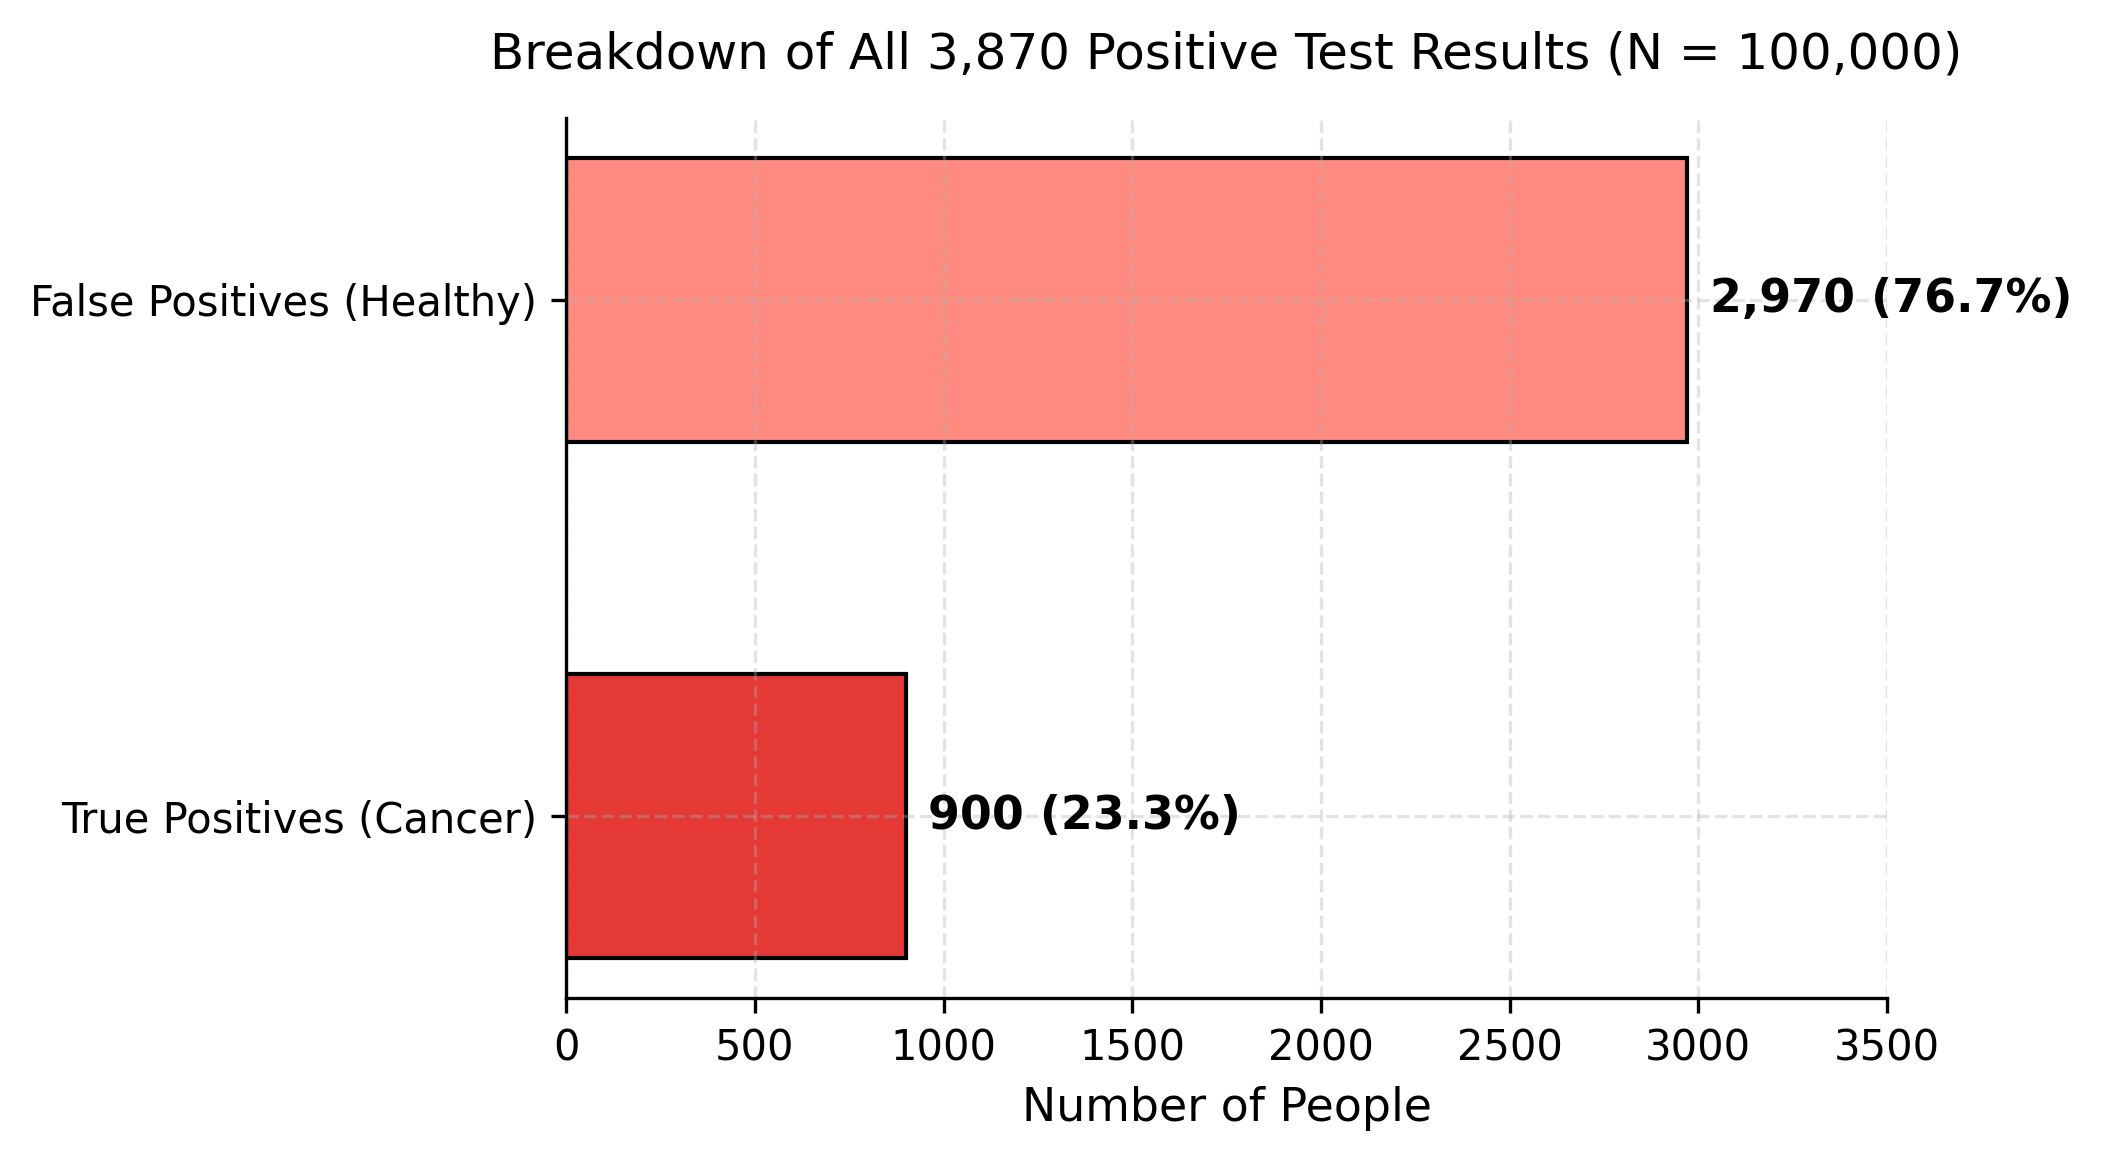

In [8]:
# 10万人規模の混同行列と陽性者の内訳可視化
total_pop = 100000
c1_count = int(total_pop * 0.01)
c0_count = total_pop - c1_count

tp = int(c1_count * 0.90)  # 900
fn = c1_count - tp         # 100
fp = int(c0_count * 0.03)  # 2970
tn = c0_count - fp         # 96030

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
categories = ['True Positives (Cancer)', 'False Positives (Healthy)']
counts = [tp, fp]
colors = ['#e53935', '#ff8a80']

bars = ax.barh(categories, counts, color=colors, edgecolor='black', height=0.55)
ax.set_xlabel('Number of People', fontsize=11)
ax.set_title(f'Breakdown of All 3,870 Positive Test Results (N = {total_pop:,})', fontsize=12, pad=12)
ax.set_xlim(0, 3500)

for bar in bars:
    w = bar.get_width()
    pct = (w / (tp + fp)) * 100
    ax.text(w + 60, bar.get_y() + bar.get_height() / 2, f'{w:,} ({pct:.1f}%)',
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#### 実験結果の分析・考察: 検査結果の内訳
- 陽性者 3,870 人のうち、健康な人が 2,970 人（$76.7\%$）を占め、真のがん患者 900 人（$23.3\%$）を大きく上回っています。
- これが、直感に反して事後確率が約 $23\%$ にとどまる直接の原因です。

---

<a id="sec_2_1_5"></a>
### 2.1.5 Prior and posterior probabilities

ここでは、事前確率と事後確率の関係、および「なぜ陽性判定でも23%にしかならないのか」という心理的直感と数理のギャップについてさらに深く考察します。

#### 1. 基準率の誤謬 (Base Rate Fallacy)
人間は条件付き確率 $p(T=1 \mid C=1) = 90\%$ という数値を聞くと、事前確率（有病率）$p(C=1) = 1\%$ という基礎的な発生頻度（**基準率 / Base Rate**）を無視しがちです。これを認知心理学において **基準率の誤謬 (Base Rate Fallacy)** と呼びます。
- がんの基準率が非常に低い（$1\%$）ため、健康な人の分母（$99\%$）が圧倒的に巨大です。
- その結果、健康な人のわずか $3\%$ の誤診であっても、$99\% \times 3\% = 2.97\%$ となり、がん患者全員の数（$1\%$）の3倍近くに達してしまうのです。

#### 2. 信念の更新 (Belief Updating)
では、この検査は役に立たないのでしょうか？決してそうではありません：
- **検査前**: 対象者ががんに罹患している確率は $p(C=1) = 1\%$ でした。
- **検査陽性後**: 確率は $p(C=1 \mid T=1) \approx 23.3\%$ へと **23倍以上に跳ね上がっています**。
- **検査陰性後**: 確率は $p(C=1 \mid T=0) \approx 0.10\%$ へと **10分の1に激減します**。

このように、事前確率（事前信念）が検査というデータ（証拠）を得ることで事後確率（事後信念）へと大きく更新されており、不確実性の削減に決定的な役割を果たしています。


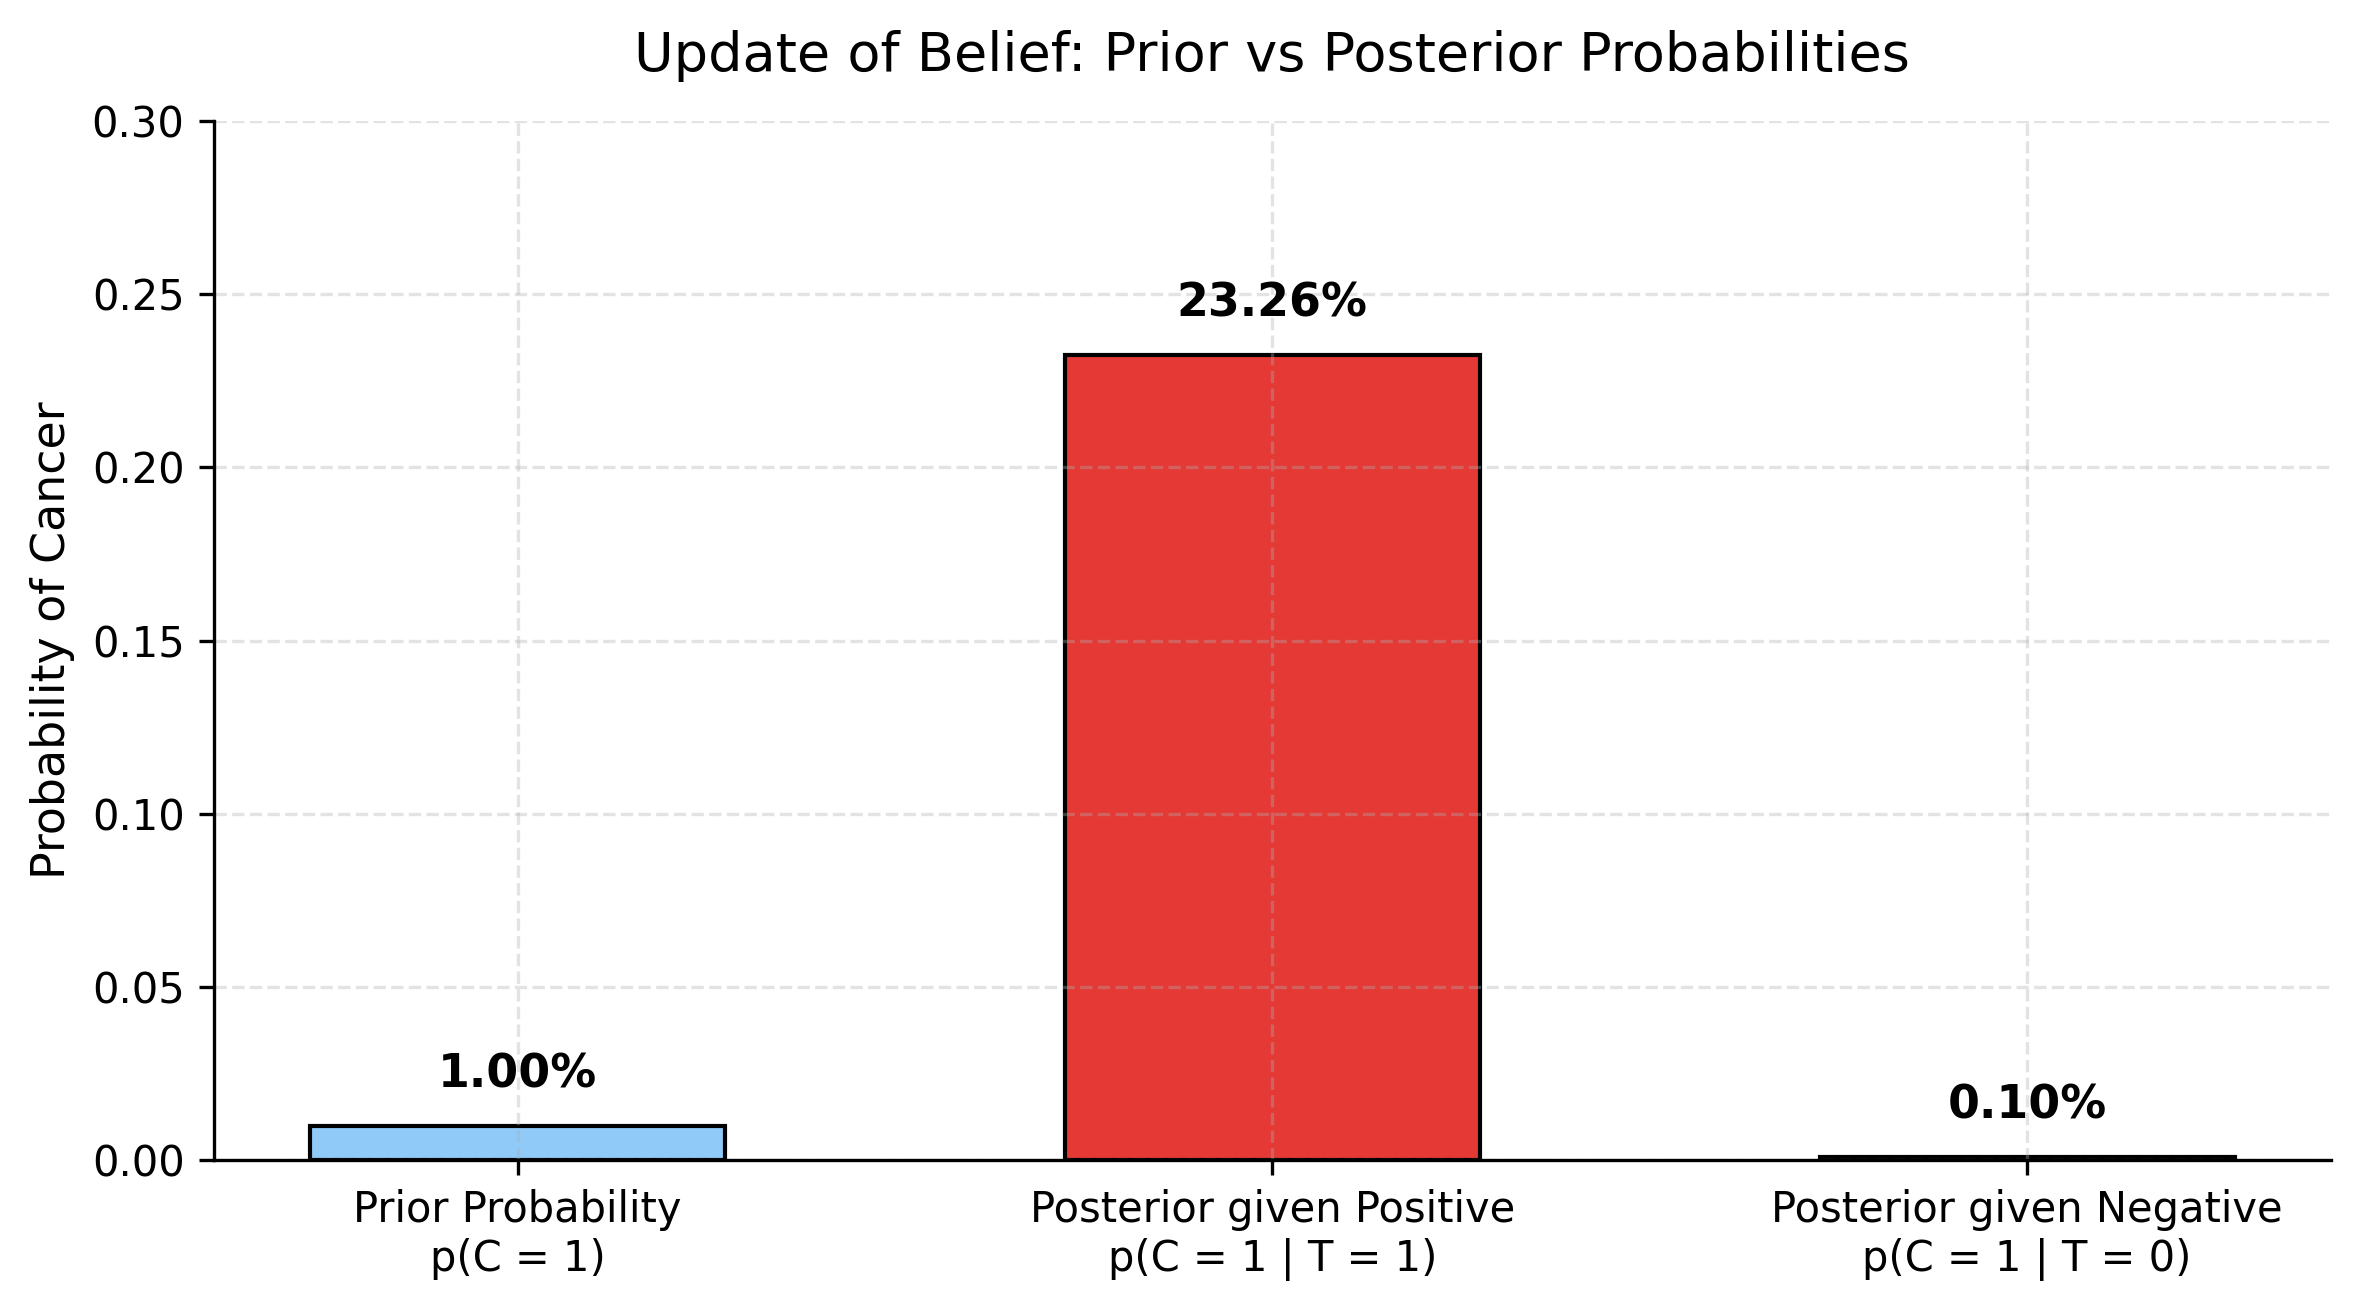

In [9]:
# 事前確率 vs 陽性事後確率 vs 陰性事後確率の比較可視化
prob_comparison = [
    med_results['p_cancer'],
    med_results['p_cancer_given_pos'],
    med_results['p_cancer_given_neg']
]
labels = [
    'Prior Probability\np(C = 1)',
    'Posterior given Positive\np(C = 1 | T = 1)',
    'Posterior given Negative\np(C = 1 | T = 0)'
]
colors = ['#90caf9', '#e53935', '#a5d6a7']

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
bars = ax.bar(labels, prob_comparison, color=colors, edgecolor='black', width=0.55)
ax.set_ylabel('Probability of Cancer', fontsize=11)
ax.set_title('Update of Belief: Prior vs Posterior Probabilities', fontsize=13, pad=12)
ax.set_ylim(0, 0.30)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008, f'{h*100:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#### 有病率（事前確率）の変化に対する事後確率の感度分析
母集団のがん有病率 $p(C=1)$ が変わったとき、陽性時の事後確率 $p(C=1 \mid T=1)$ がどのように変動するかをプロットしてみましょう。


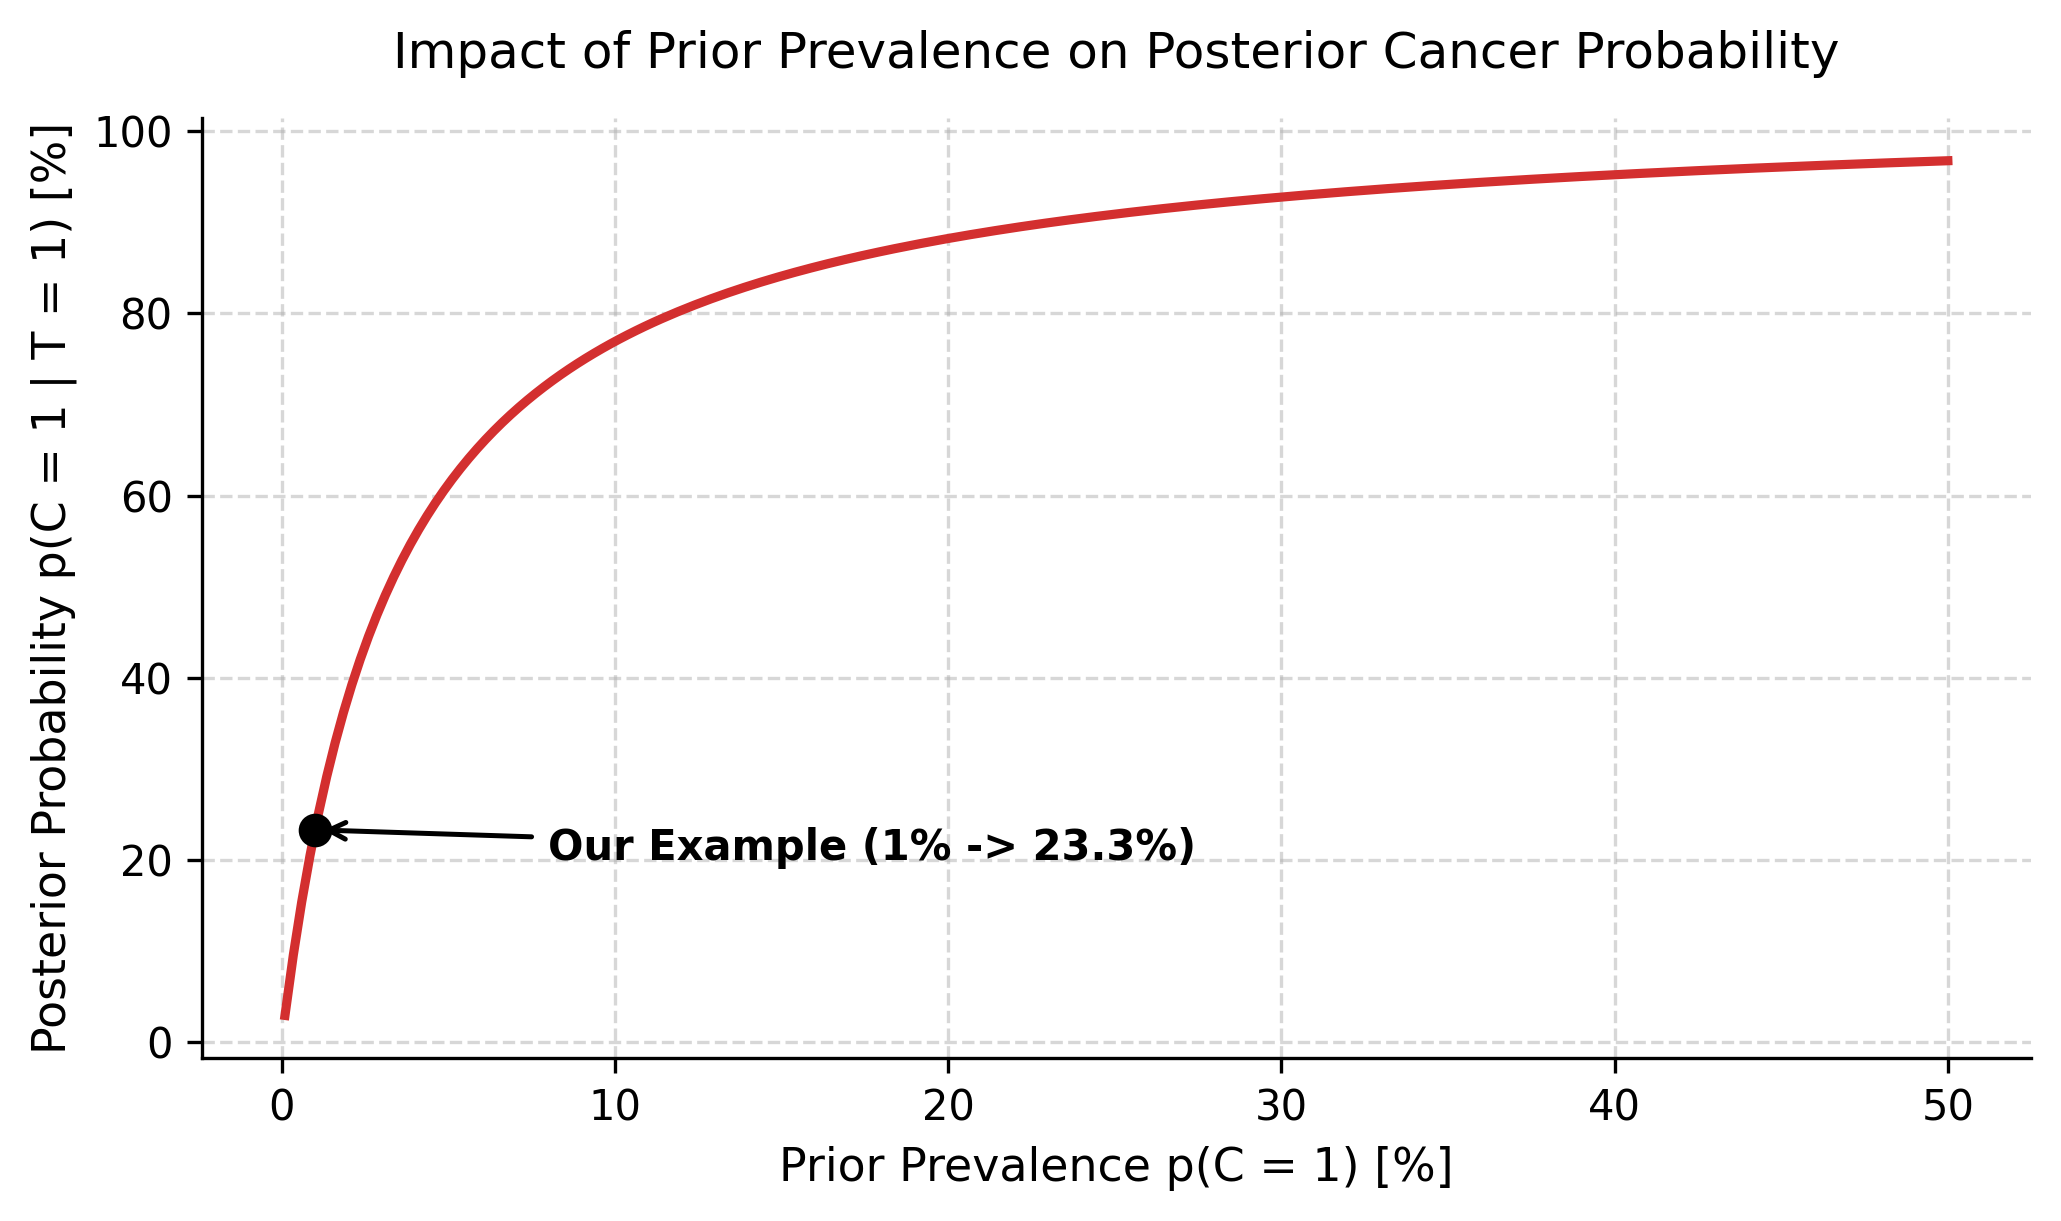

In [10]:
# 事前確率（有病率）と事後確率の関係のプロット
p_cancer_range = np.linspace(0.001, 0.50, 200)
posterior_curve = []

for p_c in p_cancer_range:
    res = medical_screening_model(p_cancer=p_c, p_pos_given_cancer=0.90, p_pos_given_no_cancer=0.03)
    posterior_curve.append(res['p_cancer_given_pos'])

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=300)
ax.plot(p_cancer_range * 100, np.array(posterior_curve) * 100, color='#d32f2f', lw=2.2)
ax.scatter([1.0], [med_results['p_cancer_given_pos'] * 100], color='black', s=50, zorder=4)
ax.annotate('Our Example (1% -> 23.3%)', xy=(1.0, 23.3), xytext=(8, 20),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
            fontsize=10, fontweight='bold')

ax.set_xlabel('Prior Prevalence p(C = 1) [%]', fontsize=11)
ax.set_ylabel('Posterior Probability p(C = 1 | T = 1) [%]', fontsize=11)
ax.set_title('Impact of Prior Prevalence on Posterior Cancer Probability', fontsize=12, pad=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 実験結果の分析・考察: 有病率と事後確率
- 有病率が $1\%$ のときは事後確率は約 $23.3\%$ ですが、有病率が $10\%$ の母集団（例えば高リスク群や自覚症状のある受診者）では、同じ検査で陽性となった場合の事後確率は約 $77\%$ に達します。
- 逆に、極めて希少な疾患（有病率 $0.1\%$）の場合、陽性が出ても真の罹患確率は $2.9\%$ にとどまります。
- **ベイズ統計における教訓**: 「検査結果（証拠）」単独では事後確率は決まらず、**「検査前の事前知識（事前分布）」と「証拠（尤度）」が合わさって初めて合理的判断が可能になる** ということが数学的に実証されました。

---

<a id="sec_2_1_6"></a>
### 2.1.6 Independent variables

2つの確率変数間の関係における最も極端で重要なケースである **独立性 (Independence)** について学びます。

#### 独立性の定義
2つの確率変数 $X, Y$ の同時分布が、それぞれの周辺確率の積に因数分解できるとき、$X$ と $Y$ は **統計的に独立 (independent)** であると定義されます：
$$p(X, Y) = p(X) p(Y) 	ag{2.23}$$

#### 条件付き確率への帰結
もし $X$ と $Y$ が独立であれば、乗法定理 $p(X, Y) = p(Y \mid X) p(X)$ と比較することにより：
$$p(Y \mid X) p(X) = p(X) p(Y) \implies p(Y \mid X) = p(Y)$$
同様に：
$$p(X \mid Y) = p(X)$$
が導かれます。
- **直感的意味**: $X$ がどんな値をとったかという情報を知っても、$Y$ の確率分布には何の影響も与えません（情報量ゼロ）。

#### 医療検査における無益な検査の数理
もしある検査が完全に無効（疾患の有無と無相関）である場合、次が成り立ちます：
$$p(T = 1 \mid C = 1) = p(T = 1 \mid C = 0) = p(T = 1)$$
これをベイズの定理に代入すると：
$$p(C = 1 \mid T = 1) = rac{p(T = 1 \mid C = 1) p(C = 1)}{p(T = 1)} = rac{p(T = 1) p(C = 1)}{p(T = 1)} = p(C = 1)$$
検査結果が陽性であっても陰性であっても、事後確率は事前確率 $p(C = 1)$ のまま全く変化しません。検査が役に立つのは、$T$ と $C$ が従属（相関）している場合に限られます。


In [11]:
# 独立性の数値シミュレーション
# Case 1: 独立な2変数
px = np.array([0.2, 0.5, 0.3])
py = np.array([0.4, 0.6])
p_indep = np.outer(px, py)

is_ind, max_diff = check_independence(p_indep)
print(f"Case 1 (外積生成分布): 独立判定 = {is_ind}, 最大偏差 = {max_diff:.2e}")

# Case 2: 従属な2変数（がんスクリーニングの同時分布）
p_c = np.array([0.99, 0.01])
# 同時分布 p(T, C) = p(T|C) * p(C)
p_joint_tc = np.array([
    [0.97 * 0.99, 0.10 * 0.01],  # T = 0
    [0.03 * 0.99, 0.90 * 0.01]   # T = 1
])
is_dep, diff_dep = check_independence(p_joint_tc)
print(f"Case 2 (がんスクリーニング): 独立判定 = {is_dep}, 最大偏差 = {diff_dep:.4f}")

Case 1 (外積生成分布): 独立判定 = True, 最大偏差 = 0.00e+00
Case 2 (がんスクリーニング): 独立判定 = False, 最大偏差 = 0.0086


#### 実験結果の分析・考察: 独立性
- Case 1 では $p(X, Y) = p(X)p(Y)$ が機械精度（$< 10^{-16}$）で成立しており、完全な独立性が確認されました。
- Case 2（がん検査）では最大偏差が約 $0.0267$ となり、独立性が明確に否定されます。この従属性（依存関係）が存在するからこそ、検査結果から疾患の事後確率を更新することが可能になります。

---

<a id="summary"></a>
### まとめと機械学習への展望

本ノートブックでは、Bishop & Bishop (2024) 第2章 2.1節に基づき、確率の規則について以下の重要項目を学び、実装・検証しました：

1. **不確実性の2つの形態**:
   - 知識不足・未観測変数による **認識的不確実性 (Epistemic)** と、本質的ノイズによる **偶然的不確実性 (Aleatoric)**。
2. **確率の2大基本規則**:
   - **加法定理 (Sum Rule)**: $p(X) = \sum_Y p(X, Y)$（不要な変数を周辺化）
   - **乗法定理 (Product Rule)**: $p(X, Y) = p(Y \mid X) p(X)$（同時確率を条件付き確率と周辺確率の積に分解）
3. **ベイズの定理 (Bayes' Theorem)**:
   - $p(Y \mid X) = rac{p(X \mid Y) p(Y)}{p(X)}$
   - 事前知識 $p(Y)$ と観測データ（尤度）$p(X \mid Y)$ を統合し、合理的な事後確率 $p(Y \mid X)$ を導く。
4. **医療診断のパラドックスと基準率の誤謬**:
   - 感度 $90\%$, 偽陽性率 $3\%$ の高精度検査であっても、有病率が $1\%$ と希少な場合、陽性時の真のがん確率は約 $23.3\%$ にとどまることを数式と10万人シミュレーションで完全解明。
5. **統計的独立性**:
   - $p(X, Y) = p(X)p(Y) \iff p(Y \mid X) = p(Y)$。データが仮説に対して情報を持つための前提条件。

#### 深層学習への接続
今後の章で学ぶニューラルネットワークの学習（最尤推定、交差エントロピー誤差関数、事後分布の推定、変分推論、拡散モデルなど）は、**すべてこの加法定理・乗法定理・ベイズの定理の上に構築** されています。基礎となる確率の規則を直感と数式の双方で完全に把握しておくことが、以後の高度な深層生成モデルやベイズ深層学習を習得する決定的な土台となります。
